<div style="color:#0F9D8A; font-size:2.8em; font-weight:700; margin-top:0.8em; margin-bottom:0.4em;">
Likelihood-free inference and exact MCMC for sums of log-normal variates
</div>

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.6em;">
General framework and objectives
</div>

We consider the following statistical model:

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell}),
\qquad i=1,\dots,n,
$$

where

$$
X_{i,\ell} \overset{i.i.d.}{\sim} \mathcal N(\mu,\sigma^2),
$$

and the parameter of interest is

$$
\theta = (\mu,\sigma^2).
$$

Given observed data

$$
y_{1:n} = (y_1,\dots,y_n),
$$

our goal is to infer the parameter $\theta$.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:0.8em;">
A fundamental difficulty: intractable likelihood
</div>

The main challenge of this problem is that the marginal distribution of

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell})
$$

has **no closed-form expression** for $L \geq 2$.

As a consequence, the likelihood

$$
p(y_{1:n} \mid \theta)
=
\prod_{i=1}^{n} p(y_i \mid \theta)
$$

cannot be evaluated explicitly.

This issue arises both:

- in a **frequentist framework**, where maximum likelihood estimation is not feasible;
- and in a **Bayesian framework**, where the posterior density

$$
\pi(\theta \mid y_{1:n}) \propto p(y_{1:n} \mid \theta)\,\pi(\theta)
$$

cannot be computed directly.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:0.8em;">
What can still be done?
</div>

Even though the likelihood is intractable, the model remains **easy to simulate from**:

- we can simulate latent variables $X_{i,\ell}$;
- and compute the corresponding observations $Y_i$.

Moreover, some **low-order moments of $Y_i$ can be derived analytically**, since $Y_i$ is a sum of independent log-normal variables.

This suggests that alternative estimation strategies could be considered, such as:

- moment-based methods (e.g. method of moments or GMM),
- or simulation-based approaches.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:0.8em;">
Strategy of the project
</div>

In this project, we focus on **simulation-based Bayesian methods** to overcome the intractability of the likelihood.

The methodology follows a progressive structure:

**(i) Likelihood-free inference (Reject-ABC)**  
We approximate the posterior distribution using simulation and a distance-based acceptance rule.

**(ii) MCMC-ABC**  
We improve computational efficiency by embedding ABC within a Markov Chain Monte Carlo framework.

**(iii) Exact inference via data augmentation**  
We introduce latent variables and construct a **Gibbs / Metropolis-within-Gibbs sampler**, which targets the exact posterior distribution.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:0.8em;">
Final objective
</div>

The final goal of the project is to:

- compare the ABC-based methods with the exact MCMC approach;
- quantify the **bias introduced by ABC** for different values of $\varepsilon$;
- and study the trade-off between computational efficiency and statistical accuracy.

<div style="color:#0F9D8A; font-size:1.4em; font-weight:700; margin-top:1em;">
Additional perspective: moment-based estimation
</div>

Although the likelihood is intractable, the structure of the model allows us to derive analytical expressions for the first moments of $Y_i$, since it is a sum of independent log-normal variables.

This suggests that alternative estimation strategies could be considered, such as moment-based methods (e.g. method of moments or Generalized Method of Moments).

While this approach is not the main focus of the project, we briefly explore it as a complementary perspective, providing a simple baseline and additional insight into the identifiability of the parameters $(\mu,\sigma^2)$.

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Why is this a "likelihood-free" problem?
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
From a tractable model to an intractable likelihood
</div>

The model is based on latent Gaussian variables:

$$
X \sim \mathcal N(\mu,\sigma^2),
$$

and the transformation

$$
Z = \exp(X),
$$

which implies that $Z$ follows a log-normal distribution.

Its density is known in closed form:

$$
f_Z(z \mid \mu,\sigma^2)
=
\frac{1}{z\sigma\sqrt{2\pi}}
\exp\left(
-\frac{(\log z-\mu)^2}{2\sigma^2}
\right),
\qquad z>0.
$$

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
The key difficulty: sums of log-normal variables
</div>

In our model, we do not observe a single log-normal variable, but a sum:

$$
Y = \sum_{\ell=1}^L Z_\ell,
\qquad Z_\ell = \exp(X_\ell),
$$

where the $Z_\ell$ are independent log-normal random variables.

The density of $Y$ is therefore given by the $L$-fold convolution:

$$
f_Y(y \mid \mu,\sigma^2)
=
(f_Z * f_Z * \cdots * f_Z)(y).
$$

This corresponds to a high-dimensional integral:

$$
f_Y(y)
=
\int_{\mathbb{R}^L}
\delta\left(y - \sum_{\ell=1}^L e^{x_\ell}\right)
\prod_{\ell=1}^L \phi(x_\ell;\mu,\sigma^2)\,dx_1\cdots dx_L.
$$

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Intractability of the likelihood
</div>

For $L \geq 2$, no closed-form expression is available for this density.

As a result, the likelihood

$$
p(y_{1:n} \mid \mu,\sigma^2)
=
\prod_{i=1}^{n} f_Y(y_i \mid \mu,\sigma^2)
$$

cannot be evaluated explicitly.

This prevents:

- maximum likelihood estimation in a frequentist framework;
- direct evaluation of the posterior distribution in a Bayesian framework.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Why likelihood-free methods apply
</div>

Despite this intractability, the model remains straightforward to simulate.

For any parameter $(\mu,\sigma^2)$, we can generate:

$$
X_{i,\ell} \sim \mathcal N(\mu,\sigma^2),
$$

and compute:

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell}).
$$

Therefore, although the likelihood is not available in closed form, we retain the ability to simulate from the model.

This combination — **intractable likelihood but tractable simulation** — is precisely the setting where likelihood-free methods such as ABC are applicable.

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Simulated observed data used throughout the project
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Data-generating process
</div>

In this project, we generate an artificial dataset from the model itself.  
This allows us to work in a controlled setting where the true parameter value is known.

We consider the following configuration:

$$
L = 10, 
\qquad
\mu_0 = 0, 
\qquad
\sigma_0 = 0.3,
$$

so that the true parameter is

$$
\theta_0 = (\mu_0,\sigma_0^2) = (0,0.09).
$$

We generate latent variables

$$
X_{i,\ell} \sim \mathcal N(0,0.3^2),
$$

and construct the observations

$$
Y_i = \sum_{\ell=1}^{10} \exp(X_{i,\ell}),
\qquad i=1,\dots,n.
$$

The resulting dataset

$$
y_{1:n}
$$

is treated as the observed data in all subsequent analyses.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Role in the project
</div>

Using simulated data plays a central role in our study:

- it allows us to **evaluate the ability of each method to recover the true parameter** $\theta_0$;
- it provides a **common benchmark** for comparing different inference procedures;
- it makes it possible to **quantify estimation bias and variability**.

All methods are applied to the same dataset:

- Reject-ABC (Part 1),
- MCMC-ABC (Part 2),
- exact MCMC via data augmentation (Part 3),
- and bias assessment of ABC methods (Part 4).

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Remark
</div>

This simulation-based setup is standard in likelihood-free inference, as it provides a ground truth against which approximate methods can be rigorously evaluated.

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
1. Reject-ABC
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
From Bayesian inference to likelihood-free approximation
</div>

We now adopt a Bayesian framework to infer the parameter

$$
\theta = (\mu,\sigma^2)
$$

from the observed data $y_{1:n}$.

The target of interest is the posterior distribution:

$$
\pi(\theta \mid y_{1:n})
=
\frac{\pi(\theta)\,p(y_{1:n} \mid \theta)}
{\int \pi(\vartheta)\,p(y_{1:n} \mid \vartheta)\,d\vartheta},
$$

or equivalently,

$$
\pi(\theta \mid y_{1:n}) \propto \pi(\theta)\,p(y_{1:n} \mid \theta).
$$

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
A fundamental obstacle
</div>

As discussed previously, the likelihood

$$
p(y_{1:n} \mid \theta)
$$

cannot be evaluated in closed form, due to the absence of an analytical expression for the density of sums of log-normal variables.

This makes direct sampling from the posterior distribution infeasible:

- we cannot compute the posterior density;
- we cannot implement standard MCMC methods that require likelihood evaluations.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Key idea of ABC
</div>

Despite this limitation, we can still simulate data from the model:

$$
z_{1:n} \sim p(\cdot \mid \theta).
$$

The core idea of Approximate Bayesian Computation (ABC) is to replace likelihood evaluation by **simulation and comparison**.

Instead of evaluating $p(y_{1:n} \mid \theta)$, we assess whether a parameter $\theta$ is plausible by checking whether it can generate data that are similar to the observed dataset.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
ABC posterior
</div>

Let $y^\star = y_{1:n}$ denote the observed data.

We introduce simulated data:

$$
z_{1:n} \sim p(\cdot \mid \theta),
$$

and define the joint ABC target:

$$
\pi_\varepsilon(\theta,z \mid y^\star)
\propto
\pi(\theta)\,p(z \mid \theta)\,
\mathbf{1}\{d(y^\star,z) \leq \varepsilon\},
$$

where:

- $d(\cdot,\cdot)$ is a distance between datasets;
- $\varepsilon > 0$ is a tolerance parameter.

The marginal ABC posterior is:

$$
\pi_\varepsilon(\theta \mid y^\star)
\propto
\pi(\theta)
\int p(z \mid \theta)\,
\mathbf{1}\{d(y^\star,z) \leq \varepsilon\}\,dz.
$$

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Choice of the distance
</div>

In this project, we compare the observed and simulated datasets using a Wasserstein-type distance inspired by the reference paper. This distance allows us to compare the empirical distributions of $y_{1:n}$ and $z_{1:n}$.

The Wasserstein distance can be understood as a transportation cost.

Imagine that the observed sample $y_{1:n}$ is one pile of mass, and the simulated sample $z_{1:n}$ is another pile of mass. The Wasserstein distance measures the minimum cost required to move the mass of the first empirical distribution so that it matches the second one.

Thus, the distance is small when the observed and simulated samples have similar values and a similar distribution, and large when the simulated sample looks very different from the observed one.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
General definition
</div>

Let $\mu$ and $\nu$ be two probability distributions.

The $p$-Wasserstein distance is defined by

$$
W_p(\mu,\nu)^p
=
\inf_{\gamma\in\Gamma(\mu,\nu)}
\int_{\mathcal Y\times\mathcal Y}
|x-y|^p\,d\gamma(x,y).
$$

Here, $\Gamma(\mu,\nu)$ is the set of all probability measures on $\mathcal Y\times\mathcal Y$ whose marginals are $\mu$ and $\nu$.
$\Gamma$ can be understood as a joint distribution of two random variables (X,Y), where 
$$
X \sim \mu,
\qquad
Y \sim \nu.
$$

The set $\Gamma(\mu,\nu)$ is the set of all possible joint distributions $\Gamma$ whose marginals are $\mu$ and $\nu$.
Thus,

$$
\int |x-y|^p\,d\gamma(x,y)
$$

can be read as

$$
\mathbb E_\gamma\left[|X-Y|^p\right].
$$

The Wasserstein distance chooses, among all joint distributions with marginals $\mu$ and $\nu$., the one that minimizes this expected cost:

$$
W_p(\mu,\nu)^p
=
\inf_{\gamma\in\Gamma(\mu,\nu)}
\mathbb E_\gamma\left[|X-Y|^p\right].
$$

In optimal transport terminology, such a joint distribution \(\gamma\) is called a transport plan. It tells us how much mass is transported from a point $x$ in the first distribution to a point $y$ in the second distribution.

The integral

$$
\int_{\mathcal Y\times\mathcal Y}
|x-y|^p\,d\gamma(x,y)
$$

is the average transportation cost under the transport plan $\gamma$.

The infimum means that we choose the transport plan with the smallest possible cost.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Empirical distributions
</div>

In the algorithm, we do not compare two abstract distributions directly. We compare two finite samples:

$$
y_{1:n}=(y_1,\dots,y_n),
\qquad
z_{1:n}=(z_1,\dots,z_n).
$$

These samples define empirical distributions:

$$
\widehat{\mu}_y
=
\frac{1}{n}\sum_{i=1}^{n}\delta_{y_i},
\qquad
\widehat{\mu}_z
=
\frac{1}{n}\sum_{j=1}^{n}\delta_{z_j}.
$$

This means that each observation carries mass $1/n$.

Since these empirical distributions are discrete, the integral in the general definition becomes a finite sum. The empirical transport problem becomes

$$
W_p(y_{1:n},z_{1:n})^p
=
\inf_{\gamma\in\Gamma_n}
\sum_{i=1}^{n}
\sum_{j=1}^{n}
|y_i-z_j|^p\gamma_{ij},
$$

where $\gamma_{ij}$ is the amount of mass transported from $y_i$ to $z_j$.

The set $\Gamma_n$ contains all matrices $\gamma=(\gamma_{ij})$ with non-negative entries such that

$$
\sum_{j=1}^{n}\gamma_{ij}
=
\frac{1}{n},
\qquad
\sum_{i=1}^{n}\gamma_{ij}
=
\frac{1}{n}.
$$

The first constraint means that each observed point $y_i$ sends total mass $1/n$.

The second constraint means that each simulated point $z_j$ receives total mass $1/n$.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Simplification in dimension one
</div>

Our data are one-dimensional. In dimension one, the optimal transport plan is obtained by sorting both samples and matching observations with the same rank.

Let

$$
y_{(1)}\leq y_{(2)}\leq \cdots \leq y_{(n)}
$$

and

$$
z_{(1)}\leq z_{(2)}\leq \cdots \leq z_{(n)}
$$

be the sorted observed and simulated samples.

Then the optimal matching is

$$
y_{(1)} \leftrightarrow z_{(1)},
\qquad
y_{(2)} \leftrightarrow z_{(2)},
\qquad
\dots,
\qquad
y_{(n)} \leftrightarrow z_{(n)}.
$$

Therefore,

$$
W_p(y_{1:n},z_{1:n})^p
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_{(i)}-z_{(i)}|^p.
$$

In this project, we use $p=1$. Thus,

$$
W_1(y_{1:n},z_{1:n})
=
\frac{1}{n}
\sum_{i=1}^{n}
|y_{(i)}-z_{(i)}|.
$$

This is the distance used in our Reject-ABC algorithm:

$$
d(y_{1:n},z_{1:n})
=
W_1(y_{1:n},z_{1:n}).
$$

And a proposed parameter is accepted if

$$
W_1(y_{1:n},z_{1:n})\leq \varepsilon.
$$

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Reject-ABC algorithm
</div>

The Reject-ABC algorithm constructs an approximate sample from $\pi_\varepsilon(\theta \mid y^\star)$ as follows.

For $j=1,\dots,N$:

1. Sample a parameter from the prior:

$$
\theta^{(j)} \sim \pi(\theta).
$$

2. Simulate a dataset:

$$
z_{1:n}^{(j)} \sim p(\cdot \mid \theta^{(j)}),
$$

that is,

$$
X_{i,\ell}^{(j)} \sim \mathcal N(\mu^{(j)},\sigma^{2(j)}),
\qquad
z_i^{(j)} = \sum_{\ell=1}^{L}\exp(X_{i,\ell}^{(j)}).
$$

3. Compute the distance:

$$
d_j = d(y_{1:n}, z_{1:n}^{(j)}).
$$

4. Accept $\theta^{(j)}$ if:

$$
d_j \leq \varepsilon.
$$

The accepted parameters form an approximate sample from the ABC posterior.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:0.8em;">
Interpretation of the ABC sample
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Posterior approximation
</div>

The accepted parameters

$$
\{\theta^{(j)} : j \in A\}, \qquad A = \{j : d_j \leq \varepsilon\},
$$

can be interpreted as an approximate sample from the ABC posterior distribution

$$
\pi_\varepsilon(\theta \mid y_{1:n}).
$$

This allows us to perform statistical inference on the parameter $\theta = (\mu,\sigma^2)$.



<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Point estimation
</div>

From the accepted sample, we can construct point estimates using standard posterior summaries.

For instance, the posterior mean estimators are:

$$
\widehat{\mu}_{ABC}
=
\frac{1}{|A|}\sum_{j\in A}\mu^{(j)},
\qquad
\widehat{\sigma^2}_{ABC}
=
\frac{1}{|A|}\sum_{j\in A}\sigma^{2(j)}.
$$

Alternatively, the empirical median can be used as a more robust estimator, especially in the presence of skewness or outliers in the accepted sample.



<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Uncertainty quantification
</div>

Beyond point estimation, the dispersion of the accepted sample provides an approximation of posterior uncertainty.

In practice, we may consider:

- empirical variances;
- interquantile ranges;
- or credible intervals based on the empirical distribution.

Thus, the ABC output can be interpreted as a full approximate posterior distribution.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:1em;">
Role of the tolerance parameter epsilon
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Bias–variance trade-off
</div>

The tolerance parameter $\varepsilon$ controls the level of approximation of the posterior.

A large value of $\varepsilon$ leads to a high acceptance rate, but allows parameters that generate datasets only loosely similar to the observed data. This results in a rough approximation of the posterior distribution.

Conversely, a small value of $\varepsilon$ enforces a stricter similarity between simulated and observed datasets, leading to a more accurate approximation of the true posterior, at the cost of a lower acceptance rate.

This induces a fundamental trade-off:

$$
\text{large } \varepsilon
\quad\Longrightarrow\quad
\text{high acceptance rate, higher bias},
$$

$$
\text{small } \varepsilon
\quad\Longrightarrow\quad
\text{low acceptance rate, lower bias}.
$$


<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Practical implementation
</div>

In practice, $\varepsilon$ is often chosen indirectly by fixing an acceptance rate (e.g., keeping the best $\alpha\%$ of simulated samples).

In the numerical experiments, we will compare different values of $\varepsilon$ (or equivalently, different acceptance quantiles) and study their impact on the inferred posterior distribution.

---

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:1em;">
Role of the prior distribution
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Choice of parametrization
</div>

We consider the prior:

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\log(\sigma^2)\sim \mathcal N(0,t^2).
$$

This parametrization ensures that $\sigma^2 > 0$ by construction, which makes it more appropriate than placing a Gaussian prior directly on $\sigma^2$.


<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Impact on exploration
</div>

The prior plays a crucial role in Reject-ABC, as parameters are sampled directly from it.

If the prior is too concentrated, it may not cover the region where the true parameter lies, leading to poor inference.

If the prior is too diffuse, many sampled parameters will generate unrealistic datasets, reducing the efficiency of the algorithm.

This leads to the trade-off:

$$
\text{overly concentrated prior}
\quad\Longrightarrow\quad
\text{risk of missing the true parameter},
$$

$$
\text{overly diffuse prior}
\quad\Longrightarrow\quad
\text{low efficiency due to wasted simulations}.
$$


<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Calibration with the true parameter
</div>

In our simulated setting, we have:

$$
\sigma_0^2 = 0.09,
\qquad
\log(\sigma_0^2)\approx -2.41.
$$

This highlights the importance of choosing $t$ appropriately: if $t$ is too small, the prior may assign negligible probability to the true value.

--- 

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700; margin-top:1em;">
Numerical implementation plan
</div>

To implement the Reject-ABC algorithm, we require:

1. a simulator for $p(y \mid \theta)$;
2. a prior sampler for $\theta$;
3. a distance function between datasets;
4. an acceptance rule based on $\varepsilon$.

We now implement these components and study how the ABC posterior depends on $\varepsilon$, $s$, and $t$.



<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Computational Framework for Reject-ABC
</div>

Before conducting the empirical analysis, we introduce the computational tools required to implement the Reject-ABC algorithm.

This section presents a modular and vectorized implementation of the main components:

- simulation of the model;
- prior sampling;
- computation of Wasserstein distances;
- implementation of the Reject-ABC procedure;
- statistical summaries and graphical diagnostics.

This structured implementation will allow us to efficiently conduct the empirical study in the next section.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 123
rng = np.random.default_rng(SEED)

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Utility Functions for Reject-ABC
</div>

In [2]:
def simulate_sum_lognormal(n, L, mu, sigma, rng):
    X = rng.normal(loc=mu, scale=sigma, size=(n, L))
    return np.exp(X).sum(axis=1)

def simulate_sum_lognormal_many(n, L, mu_samples, sigma_samples, rng):
    """
    Simulates N datasets, each of size n, for N parameter values.
    Output has shape (N, n).
    """
    N = len(mu_samples)
    X = rng.normal(
        loc=mu_samples[:, None, None],
        scale=sigma_samples[:, None, None],
        size=(N, n, L)
    )
    return np.exp(X).sum(axis=2)

def wasserstein_1d_many(y_obs, z_sim_all):
    """
    Computes W1 distance between y_obs and each simulated dataset.
    z_sim_all has shape (N, n).
    """
    y_sorted = np.sort(y_obs)
    z_sorted = np.sort(z_sim_all, axis=1)
    return np.mean(np.abs(z_sorted - y_sorted[None, :]), axis=1)

def sample_prior(N, s, t, rng):
    mu = rng.normal(0.0, s, size=N)
    eta = rng.normal(0.0, t, size=N)
    sigma2 = np.exp(eta)
    sigma = np.sqrt(sigma2)
    return mu, sigma2, sigma

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Efficient Vectorized Implementation of the Reject-ABC Algorithm with Quantile-Based Acceptance
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Vectorized implementation of Reject-ABC
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Algorithmic principle
</div>

We now implement the Reject-ABC algorithm described above in a vectorized form.

Given $N$ independent draws from the prior,

$$
\theta^{(j)} = (\mu^{(j)}, \sigma^{2(j)}), \qquad j=1,\dots,N,
$$

we simulate, for each parameter value, a synthetic dataset

$$
z_{1:n}^{(j)} \sim p(\cdot \mid \theta^{(j)}),
$$

compute its Wasserstein distance to the observed dataset $y_{1:n}$,

$$
d_j = d(y_{1:n}, z_{1:n}^{(j)}),
$$

and accept the parameter if this distance is smaller than a tolerance level $\varepsilon$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Quantile-based acceptance rule
</div>

In practice, the scale of the Wasserstein distances is not known in advance, which makes it difficult to specify a suitable value of $\varepsilon$ directly.

To overcome this issue, we adopt a quantile-based approach. After computing the distances

$$
d_1,\dots,d_N,
$$

we define the tolerance as

$$
\varepsilon = Q_q(d_1,\dots,d_N),
$$

where $Q_q$ denotes the empirical $q$-quantile.

This implies that we accept the best proportion $q$ of simulated parameters:

$$
\text{accept } \theta^{(j)} \quad \text{if} \quad d_j \leq \varepsilon.
$$

For instance, if

$$
N = 20{,}000 \quad \text{and} \quad q = 0.01,
$$

then approximately $200$ parameter values are retained.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Computational advantage
</div>

The implementation below leverages vectorized simulation:

- all parameter values are sampled at once;
- all synthetic datasets are generated simultaneously;
- all distances are computed in parallel.

This avoids explicit loops over $j=1,\dots,N$, leading to a significant improvement in computational efficiency, which is crucial for large-scale ABC experiments.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Output
</div>

The function returns:

- the full set of simulated parameters and distances;
- the subset of accepted parameters;
- the selected tolerance level $\varepsilon$.

The accepted sample can then be interpreted as an approximate draw from the ABC posterior distribution.

In [3]:
def reject_abc_vectorized(y_obs, L, N, s, t, rng, epsilon=None, q=None):
    if epsilon is None and q is None:
        raise ValueError("Provide either epsilon or q.")
        
    n = len(y_obs)
    
    mu_samples, sigma2_samples, sigma_samples = sample_prior(N, s, t, rng)
    
    z_sim_all = simulate_sum_lognormal_many(
        n=n,
        L=L,
        mu_samples=mu_samples,
        sigma_samples=sigma_samples,
        rng=rng
    )
    
    distances = wasserstein_1d_many(y_obs, z_sim_all)
    
    if epsilon is None:
        epsilon_used = np.quantile(distances, q)
    else:
        epsilon_used = epsilon
    
    accepted = distances <= epsilon_used
    
    results = pd.DataFrame({
        "mu": mu_samples,
        "sigma2": sigma2_samples,
        "sigma": sigma_samples,
        "distance": distances,
        "accepted": accepted
    })
    
    accepted_results = results.loc[accepted].copy()
    
    return results, accepted_results, epsilon_used

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior Summary and Estimation Accuracy for ABC Samples
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Posterior summary of ABC samples
</div>

To interpret the output of the Reject-ABC algorithm, we summarize the accepted parameter values using standard posterior statistics.

In particular, we compute:

- posterior means and medians as point estimators;
- posterior standard deviations to quantify uncertainty;
- the deviation from the true parameter values, which allows us to assess the accuracy of the ABC approximation.

This provides a concise statistical summary of the approximate posterior distribution obtained from ABC.

In [4]:
def summarize_abc_samples(abc_samples, mu_true, sigma2_true):
    summary = abc_samples[["mu", "sigma2", "sigma"]].describe().T
    
    estimates = pd.DataFrame({
        "posterior_mean": abc_samples[["mu", "sigma2", "sigma"]].mean(),
        "posterior_median": abc_samples[["mu", "sigma2", "sigma"]].median(),
        "posterior_sd": abc_samples[["mu", "sigma2", "sigma"]].std()
    })
    
    estimates.loc["mu", "true_value"] = mu_true
    estimates.loc["sigma2", "true_value"] = sigma2_true
    estimates.loc["sigma", "true_value"] = np.sqrt(sigma2_true)
    
    estimates["absolute_error_median"] = np.abs(
        estimates["posterior_median"] - estimates["true_value"]
    )
    
    return estimates

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior Summary and Estimation Accuracy for ABC Samples
</div>

We now visualize the marginal and joint distributions of the accepted ABC samples.

These graphical representations provide insight into:
- the concentration of the posterior around the true parameter values,
- the uncertainty associated with each parameter,
- and the dependence structure between $\mu$ and $\sigma^2$.

In [5]:
def plot_abc_marginals(abc_samples, mu_true, sigma2_true):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    
    axes[0].hist(abc_samples["mu"], bins=30, density=True, alpha=0.7)
    axes[0].axvline(mu_true, linestyle="--", label="true value")
    axes[0].axvline(abc_samples["mu"].median(), linestyle="-", label="ABC median")
    axes[0].set_title(r"Accepted ABC samples for $\mu$")
    axes[0].set_xlabel(r"$\mu$")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    
    axes[1].hist(abc_samples["sigma2"], bins=30, density=True, alpha=0.7)
    axes[1].axvline(sigma2_true, linestyle="--", label="true value")
    axes[1].axvline(abc_samples["sigma2"].median(), linestyle="-", label="ABC median")
    axes[1].set_title(r"Accepted ABC samples for $\sigma^2$")
    axes[1].set_xlabel(r"$\sigma^2$")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    
    fig.tight_layout()
    plt.show()

def plot_abc_joint(abc_samples, mu_true, sigma2_true):
    plt.figure(figsize=(6, 5))
    plt.scatter(abc_samples["mu"], abc_samples["sigma2"], alpha=0.5, s=15)
    plt.axvline(mu_true, linestyle="--", label=r"true $\mu$")
    plt.axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
    plt.xlabel(r"$\mu$")
    plt.ylabel(r"$\sigma^2$")
    plt.title(r"Accepted ABC samples in the $(\mu,\sigma^2)$ plane")
    plt.legend()
    plt.show()

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Monte Carlo Error Assessment for Reject-ABC
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Monte Carlo error assessment for Reject-ABC
</div>

Reject-ABC is based on random prior draws and simulated datasets. Therefore, the posterior summaries obtained from a single run may be affected by Monte Carlo variability.

To assess this numerical error, we repeat the Reject-ABC algorithm several times using independent random seeds. For each run, we record the selected tolerance level, the number of accepted samples, and posterior summaries of the accepted parameters.

This allows us to evaluate the stability of the ABC estimates and to separate, at least empirically, the ABC approximation error from the simulation error due to a finite number of Monte Carlo draws.

In [6]:
def repeated_reject_abc(y_obs, L, N, s, t, q, R, base_seed=123):
    rows = []
    
    for r in range(R):
        rng_r = np.random.default_rng(base_seed + r)
        all_res, acc_res, eps = reject_abc_vectorized(
            y_obs=y_obs,
            L=L,
            N=N,
            s=s,
            t=t,
            rng=rng_r,
            q=q
        )
        
        rows.append({
            "run": r + 1,
            "epsilon": eps,
            "n_accepted": len(acc_res),
            "mu_median": acc_res["mu"].median(),
            "mu_mean": acc_res["mu"].mean(),
            "sigma2_median": acc_res["sigma2"].median(),
            "sigma2_mean": acc_res["sigma2"].mean(),
            "mean_distance_accepted": acc_res["distance"].mean()
        })
    
    return pd.DataFrame(rows)

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Empirical Study of Reject-ABC Performance
</div>

We now use the functions defined above to study the empirical behavior of Reject-ABC on the simulated observed dataset.

The goal of this section is to assess:

- whether Reject-ABC recovers the true parameter values;
- how the posterior approximation changes with the tolerance level;
- how the prior parameters $(s,t)$ affect the algorithm;
- and how stable the estimates are across independent Monte Carlo runs.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Main Reject-ABC run
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Baseline Reject-ABC experiment
</div>

We first run Reject-ABC with a baseline prior and a quantile-based tolerance rule.

We use:

$$
s=1,\qquad t=2,
$$

and keep the best \(1\%\) of the simulations according to the Wasserstein distance.

In [7]:
# --- Data generation ---
n = 200
L = 10
mu_true = 0.0
sigma_true = 0.3
sigma2_true = sigma_true**2

y_obs = simulate_sum_lognormal(n, L, mu_true, sigma_true, rng)

# --- ABC settings ---
N = 20_000
s = 1.0
t = 2.0
q = 0.01

all_results, abc_samples, epsilon_used = reject_abc_vectorized(
    y_obs=y_obs,
    L=L,
    N=N,
    s=s,
    t=t,
    rng=rng,   
    q=q
)

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior summaries
</div>

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Posterior summaries and estimation accuracy
</div>

We summarize the accepted ABC samples using posterior means, medians and standard deviations.

Since the data are simulated from known parameters, we can directly compare the ABC estimates with the true values.

In [8]:
abc_estimates = summarize_abc_samples(
    abc_samples=abc_samples,
    mu_true=mu_true,
    sigma2_true=sigma2_true
)

abc_estimates.round(4)

,posterior_mean,posterior_median,posterior_sd,true_value,absolute_error_median
mu,-0.0055,-0.0040,0.0438,0.00,0.0040
sigma2,0.1095,0.1027,0.0642,0.09,0.0127
sigma,0.3147,0.3204,0.1024,0.30,0.0204


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of posterior estimates
</div>

This table provides a quantitative assessment of the ABC posterior estimates and their ability to recover the true parameter values.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of mu
</div>

For the location parameter $\mu$, both the posterior mean and median are very close to the true value $\mu_0 = 0$.

- the absolute error based on the posterior median is very small (around $0.004$);
- the posterior distribution is well centered;
- and the posterior standard deviation remains low.

This indicates that $\mu$ is **accurately and precisely estimated**, with limited uncertainty.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of sigma^2
</div>

For the variance parameter $\sigma^2$, the estimation is slightly less accurate.

- the posterior median (approximately $0.103$) is higher than the true value ($0.09$);
- leading to a moderate absolute error;
- and the posterior standard deviation is larger than for $\mu$.

This reflects a **higher level of uncertainty** and a slight upward bias in the estimation of $\sigma^2$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of sigma
</div>

A similar pattern is observed for $\sigma$, which is a nonlinear transformation of $\sigma^2$.

- the posterior median remains close to the true value;
- however, the dispersion is larger.

This is expected, as uncertainty propagates through the square root transformation.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation
</div>

These results highlight two key features of the Reject-ABC estimator:

- the method performs well in recovering the **central tendency** of the parameters, especially for $\mu$;
- however, the estimation of $\sigma^2$ is more uncertain and slightly biased.

This difference reflects both:

- the intrinsic difficulty of estimating scale parameters;
- and the approximation error induced by the tolerance parameter $\varepsilon$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

Overall, Reject-ABC provides a reliable approximation of the posterior distribution in this baseline setting. 

At the same time, these results emphasize the importance of:

- carefully calibrating the tolerance level;
- and assessing uncertainty through posterior dispersion rather than point estimates alone.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Graphical analysis of the ABC posterior
</div> 

We now visualize the marginal distributions of the accepted parameters and their joint distribution in the \((\mu,\sigma^2)\) plane.

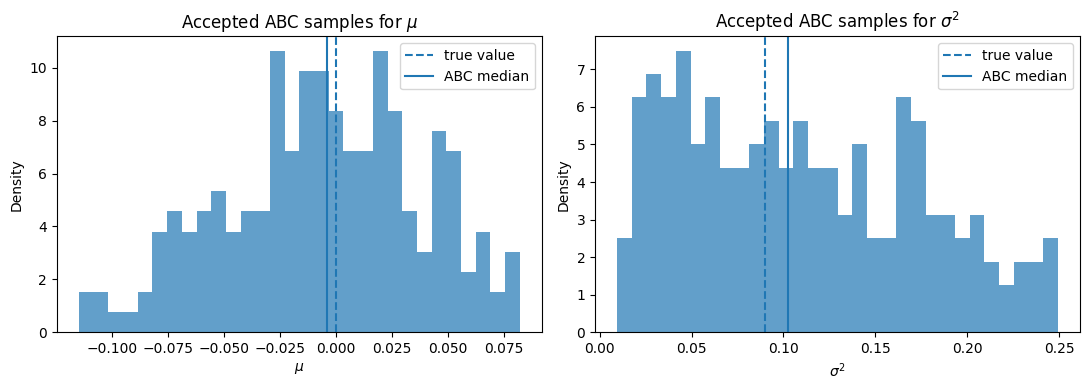

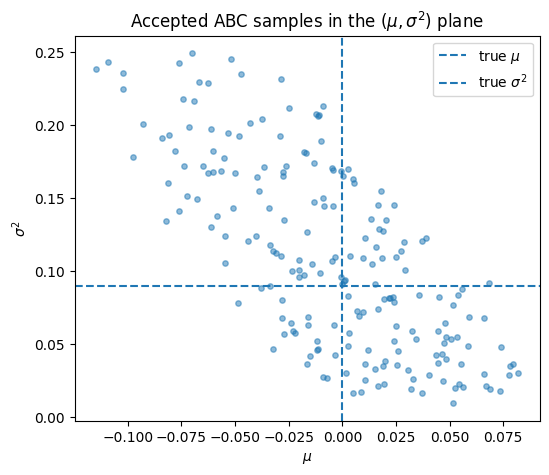

In [9]:
plot_abc_marginals(
    abc_samples=abc_samples,
    mu_true=mu_true,
    sigma2_true=sigma2_true
)

plot_abc_joint(
    abc_samples=abc_samples,
    mu_true=mu_true,
    sigma2_true=sigma2_true
)

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Graphical posterior analysis — Interpretation
</div>

The marginal histograms and the joint scatter plot provide a comprehensive assessment of how well the ABC posterior concentrates around the true parameter values.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of mu
</div>

For $\mu$, the distribution of accepted samples is clearly centered around the true value $\mu_0 = 0$.

- the posterior median is very close to the true parameter;
- the distribution is tightly concentrated;
- and the spread remains limited.

This indicates that the **location parameter is both accurately and precisely estimated**, with low uncertainty, in line with the numerical summaries.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of sigma^2
</div>

For $\sigma^2$, the posterior distribution is more dispersed and exhibits a slight right skewness.

- the ABC median remains close to the true value $\sigma_0^2 = 0.09$;
- however, a non-negligible mass of accepted values lies above the true parameter;
- leading to a visible upward bias in the posterior mean.

This reflects a **higher level of uncertainty in the estimation of the variance parameter**, which is inherently more difficult to identify.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Dependence structure between mu and sigma^2
</div>

The joint scatter plot reveals a clear negative dependence between $\mu$ and $\sigma^2$:

- lower values of $\mu$ are associated with higher values of $\sigma^2$;
- higher values of $\mu$ are associated with lower values of $\sigma^2$.

This phenomenon is a direct consequence of the model structure. Indeed, the expected value of the observations satisfies

$$
\mathbb{E}[Y_i] = L \exp\left(\mu + \frac{\sigma^2}{2}\right).
$$

As a result, different combinations of $(\mu, \sigma^2)$ can produce similar expected values. The ABC algorithm therefore tends to accept parameter pairs lying along curves where

$$
\mu + \frac{\sigma^2}{2} \approx \text{constant}.
$$

This induces a **compensation mechanism** between the two parameters in the accepted sample.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation
</div>

These graphical diagnostics confirm that:

- Reject-ABC successfully identifies a region of the parameter space consistent with the observed data;
- the estimation of $\mu$ is more precise than that of $\sigma^2$;
- and the dependence structure between parameters is a natural consequence of both the model and the ABC acceptance mechanism.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

Overall, these results highlight both the strengths and the limitations of Reject-ABC: while the method provides a coherent approximation of the posterior distribution, it also exhibits parameter-specific uncertainty and structural dependencies. 

These observations naturally motivate a deeper investigation of the role of the tolerance parameter and the prior distribution in the following sections.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Observed vs simulated data under ABC estimate
</div> 

<div style="color:#3A7BD5; font-size:1.35em; font-weight:700;">
Posterior predictive check
</div>

As a simple diagnostic, we simulate a new dataset using the ABC posterior median and compare it with the observed dataset.

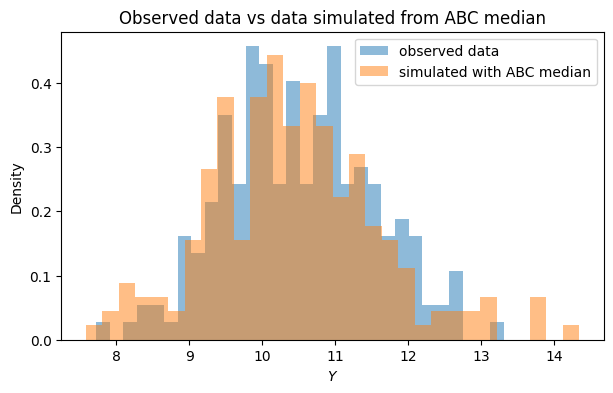

In [10]:
mu_abc_median = abc_samples["mu"].median()
sigma2_abc_median = abc_samples["sigma2"].median()
sigma_abc_median = np.sqrt(sigma2_abc_median)

rng_check = np.random.default_rng(456)

z_abc = simulate_sum_lognormal(
    n=n,
    L=L,
    mu=mu_abc_median,
    sigma=sigma_abc_median,
    rng=rng_check
)

plt.figure(figsize=(7, 4))
plt.hist(y_obs, bins=30, density=True, alpha=0.5, label="observed data")
plt.hist(z_abc, bins=30, density=True, alpha=0.5, label="simulated with ABC median")
plt.xlabel(r"$Y$")
plt.ylabel("Density")
plt.title("Observed data vs data simulated from ABC median")
plt.legend()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Posterior predictive check — Interpretation
</div>

This figure compares the observed dataset with a dataset simulated from the ABC posterior median, providing a visual diagnostic of the model fit.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global agreement between distributions
</div>

The two histograms are globally well aligned, indicating that the dataset simulated from the ABC posterior median successfully reproduces the main features of the observed data.

In particular:

- both distributions are centered around similar values (approximately between 10 and 11);
- they exhibit comparable dispersion;
- and their overall shapes are consistent.

This suggests that the **central tendency and variability** of the data are well captured by the ABC estimate.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Distributional features
</div>

Both histograms display a slight right skewness, which is consistent with the log-normal structure of the model. 

This indicates that the ABC procedure correctly captures not only the first-order moments, but also important distributional characteristics of the data.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Discrepancies in the tails
</div>

Despite this overall agreement, some discrepancies remain, particularly in the tails:

- the simulated data appear slightly more dispersed;
- a few larger values are present in the simulated sample but less frequent in the observed data.

These differences reflect:

- the residual uncertainty in the estimation of $\sigma^2$;
- and the approximation error introduced by the ABC procedure.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Probabilistic interpretation
</div>

This comparison can be interpreted as a **posterior predictive check**: we assess whether parameters drawn from the approximate posterior distribution are able to generate data consistent with the observed dataset.

The close alignment between the two distributions indicates that the ABC posterior median provides a **reasonable and coherent fit** to the data.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

Overall, this diagnostic confirms that Reject-ABC identifies parameter values that are compatible with the observed data. 

At the same time, it highlights that some variability remains, particularly in the tails, which is a typical feature of likelihood-free inference methods and reflects both estimation uncertainty and approximation error.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Effect of the tolerance parameter
</div> 

We now study how the ABC approximation changes when the tolerance level varies.

Instead of fixing $\varepsilon$ directly, we use different acceptance quantiles $q$.  
Smaller values of $q$ correspond to stricter acceptance rules.

In [11]:
def summarize_epsilon_effect(all_results, quantiles):
    rows = []

    for q_val in quantiles:
        eps = np.quantile(all_results["distance"], q_val)
        acc = all_results.loc[all_results["distance"] <= eps]

        rows.append({
            "q": q_val,
            "epsilon": eps,
            "n_accepted": len(acc),
            "acceptance_rate": len(acc) / len(all_results),
            "mu_median": acc["mu"].median(),
            "mu_mean": acc["mu"].mean(),
            "mu_sd": acc["mu"].std(),
            "sigma2_median": acc["sigma2"].median(),
            "sigma2_mean": acc["sigma2"].mean(),
            "sigma2_sd": acc["sigma2"].std(),
            "mean_distance_accepted": acc["distance"].mean()
        })

    return pd.DataFrame(rows)

In [12]:
quantiles = [0.001, 0.005, 0.01, 0.02, 0.05]

epsilon_summary = summarize_epsilon_effect(
    all_results=all_results,
    quantiles=quantiles
)

epsilon_summary.round(4)

,q,epsilon,n_accepted,acceptance_rate,mu_median,mu_mean,mu_sd,sigma2_median,sigma2_mean,sigma2_sd,mean_distance_accepted
0,0.001,0.1705,20,0.001,0.0010,0.0006,0.0149,0.0950,0.0938,0.0141,0.1347
1,0.005,0.3960,100,0.005,0.0010,0.0001,0.0302,0.0938,0.0972,0.0441,0.2688
2,0.010,0.5792,200,0.010,-0.0040,-0.0055,0.0438,0.1027,0.1095,0.0642,0.3761
3,0.020,0.9213,400,0.020,-0.0203,-0.0216,0.0644,0.1169,0.1331,0.0954,0.5712
4,0.050,1.7238,1000,0.050,-0.0714,-0.0732,0.1254,0.1766,0.2177,0.1741,1.0353


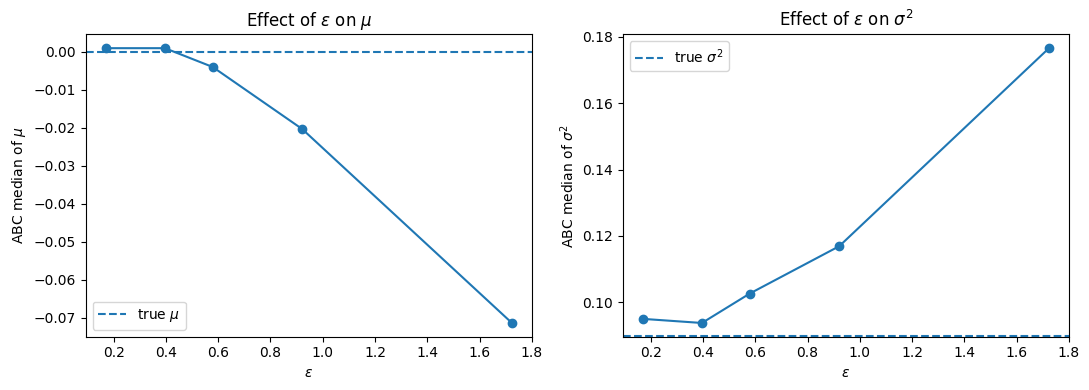

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epsilon_summary["epsilon"], epsilon_summary["mu_median"], marker="o")
axes[0].axhline(mu_true, linestyle="--", label=r"true $\mu$")
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel(r"ABC median of $\mu$")
axes[0].set_title(r"Effect of $\varepsilon$ on $\mu$")
axes[0].legend()

axes[1].plot(epsilon_summary["epsilon"], epsilon_summary["sigma2_median"], marker="o")
axes[1].axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel(r"ABC median of $\sigma^2$")
axes[1].set_title(r"Effect of $\varepsilon$ on $\sigma^2$")
axes[1].legend()

fig.tight_layout()
plt.show()


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Impact of the tolerance parameter epsilon — Interpretation
</div>

These plots provide a clear illustration of how the tolerance parameter $\varepsilon$ influences the ABC posterior approximation.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect of a small tolerance
</div>

For small values of $\varepsilon$, the acceptance criterion is highly restrictive: only simulated datasets that are very close to the observed data are retained.

As a consequence:

- the ABC posterior medians for both $\mu$ and $\sigma^2$ remain close to their true values;
- the approximation of the true posterior distribution is accurate;
- but the number of accepted samples is limited.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect of a large tolerance
</div>

As $\varepsilon$ increases, the acceptance rule becomes less restrictive. The algorithm starts accepting parameter values that generate datasets which are less similar to the observed data.

This leads to a systematic deterioration of the estimates:

- the median of $\mu$ decreases and becomes increasingly negative;
- the median of $\sigma^2$ increases significantly above the true value.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Underlying mechanism
</div>

This behavior is consistent with the dependence structure between $\mu$ and $\sigma^2$, already observed in the joint posterior analysis.

Indeed, the expected value of the observations satisfies

$$
\mathbb{E}[Y_i] = L \exp\left(\mu + \frac{\sigma^2}{2}\right).
$$

Therefore, different combinations of $(\mu, \sigma^2)$ can produce similar values of $\mathbb{E}[Y_i]$:

- larger values of $\sigma^2$ can be compensated by smaller values of $\mu$;
- conversely, smaller values of $\sigma^2$ can be offset by larger values of $\mu$.

When $\varepsilon$ is large, this compensation mechanism becomes more pronounced, allowing a wider range of parameter combinations to be accepted.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Statistical trade-off
</div>

Overall, these results highlight the fundamental trade-off induced by the tolerance parameter:

$$
\text{small } \varepsilon
\quad \Longrightarrow \quad
\text{accurate approximation but low acceptance rate},
$$

$$
\text{large } \varepsilon
\quad \Longrightarrow \quad
\text{higher acceptance rate but increased bias}.
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

The tolerance parameter $\varepsilon$ is a key component of the Reject-ABC algorithm. It directly controls the balance between statistical accuracy and computational efficiency, and must therefore be carefully calibrated in practice.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Effect of the prior parameters
</div> 

We now investigate how the prior hyperparameters $s$ and $t$ affect Reject-ABC.

The parameter $s$ controls the prior dispersion of $\mu$, while $t$ controls the prior dispersion of $\log(\sigma^2)$.

This is important because Reject-ABC samples parameters directly from the prior.

In [14]:
def run_prior_sensitivity(y_obs, L, N_grid, s_values, t_values, q, base_seed=10_000):
    rows = []

    for k, (s_val, t_val) in enumerate((s_val, t_val) for s_val in s_values for t_val in t_values):
        rng_grid = np.random.default_rng(base_seed + k)

        all_res, acc_res, eps = reject_abc_vectorized(
            y_obs=y_obs,
            L=L,
            N=N_grid,
            s=s_val,
            t=t_val,
            rng=rng_grid,
            q=q
        )

        rows.append({
            "s": s_val,
            "t": t_val,
            "epsilon": eps,
            "n_accepted": len(acc_res),
            "acceptance_rate": len(acc_res) / N_grid,
            "mu_median": acc_res["mu"].median(),
            "mu_mean": acc_res["mu"].mean(),
            "mu_sd": acc_res["mu"].std(),
            "sigma2_median": acc_res["sigma2"].median(),
            "sigma2_mean": acc_res["sigma2"].mean(),
            "sigma2_sd": acc_res["sigma2"].std()
        })

    summary = pd.DataFrame(rows)

    summary["mu_abs_error"] = np.abs(summary["mu_median"] - mu_true)
    summary["sigma2_abs_error"] = np.abs(summary["sigma2_median"] - sigma2_true)
    summary["total_abs_error"] = summary["mu_abs_error"] + summary["sigma2_abs_error"]

    return summary

In [15]:
s_values = [0.5, 1.0, 2.0]
t_values = [0.5, 1.0, 2.0, 3.0]

N_grid = 10_000
q_grid = 0.01

prior_summary = run_prior_sensitivity(
    y_obs=y_obs,
    L=L,
    N_grid=N_grid,
    s_values=s_values,
    t_values=t_values,
    q=q_grid
)

prior_summary.round(4)

/tmp/ipykernel_96126/1301985205.py:16: RuntimeWarning: overflow encountered in exp
  return np.exp(X).sum(axis=2)
/tmp/ipykernel_96126/1301985205.py:16: RuntimeWarning: overflow encountered in exp
  return np.exp(X).sum(axis=2)
/tmp/ipykernel_96126/1301985205.py:16: RuntimeWarning: overflow encountered in exp
  return np.exp(X).sum(axis=2)


,s,t,epsilon,n_accepted,acceptance_rate,mu_median,mu_mean,mu_sd,sigma2_median,sigma2_mean,sigma2_sd,mu_abs_error,sigma2_abs_error,total_abs_error
0,0.5,0.5,1.2684,100,0.01,-0.1394,-0.1447,0.0643,0.3969,0.4023,0.0807,0.1394,0.3069,0.4462
1,0.5,1.0,0.7167,100,0.01,-0.0495,-0.0437,0.0483,0.1893,0.1846,0.0728,0.0495,0.0993,0.1488
2,0.5,2.0,0.4404,100,0.01,-0.0022,-0.0013,0.0331,0.0780,0.0913,0.0497,0.0022,0.0120,0.0142
3,0.5,3.0,0.3954,100,0.01,0.0056,0.0022,0.0301,0.0964,0.0971,0.0457,0.0056,0.0064,0.0120
4,1.0,0.5,1.4836,100,0.01,-0.1959,-0.1805,0.0833,0.4359,0.4314,0.1057,0.1959,0.3459,0.5418
5,1.0,1.0,0.9562,100,0.01,-0.0708,-0.0687,0.0546,0.2268,0.2303,0.0901,0.0708,0.1368,0.2076
6,1.0,2.0,0.6066,100,0.01,-0.0069,-0.0062,0.0470,0.1002,0.1093,0.0707,0.0069,0.0102,0.0171
7,1.0,3.0,0.5620,100,0.01,0.0044,0.0024,0.0467,0.0713,0.0932,0.0644,0.0044,0.0187,0.0231
8,2.0,0.5,1.7473,100,0.01,-0.2526,-0.2308,0.0929,0.5408,0.5271,0.1207,0.2526,0.4508,0.7034
9,2.0,1.0,1.2728,100,0.01,-0.1138,-0.1073,0.0764,0.3101,0.2920,0.1132,0.1138,0.2201,0.3339


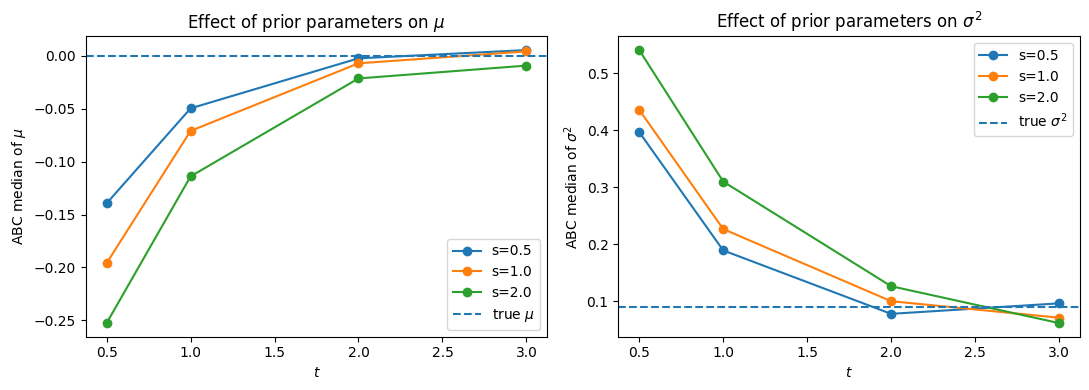

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for s_val in s_values:
    sub = prior_summary[prior_summary["s"] == s_val].sort_values("t")

    axes[0].plot(sub["t"], sub["mu_median"], marker="o", label=f"s={s_val}")
    axes[1].plot(sub["t"], sub["sigma2_median"], marker="o", label=f"s={s_val}")

axes[0].axhline(mu_true, linestyle="--", label=r"true $\mu$")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel(r"ABC median of $\mu$")
axes[0].set_title(r"Effect of prior parameters on $\mu$")
axes[0].legend()

axes[1].axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel(r"ABC median of $\sigma^2$")
axes[1].set_title(r"Effect of prior parameters on $\sigma^2$")
axes[1].legend()

fig.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of the effect of the prior parameters
</div>

These plots highlight the strong influence of the prior distribution on the ABC estimates, particularly through the hyperparameters $s$ and $t$.

We recall that the prior is defined as:

$$
\mu \sim \mathcal N(0,s^2), \qquad \log(\sigma^2) \sim \mathcal N(0,t^2),
$$

so that $s$ controls the dispersion of $\mu$, while $t$ controls the dispersion of $\log(\sigma^2)$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect on mu
</div>

For small values of $t$, the ABC median of $\mu$ is strongly biased downward (negative values), especially when $s$ is large. This behavior is a direct consequence of the prior misspecification on $\sigma^2$.

Indeed, when $t$ is small, the prior on $\log(\sigma^2)$ is highly concentrated around $0$, which implies that $\sigma^2$ is typically proposed near $\exp(0)=1$. This is far from the true value $\sigma_0^2=0.09$.

To compensate for these overly large values of $\sigma^2$, the algorithm selects smaller values of $\mu$, which explains the negative bias observed. This compensation mechanism is consistent with the model structure:

$$
\mathbb{E}[Y_i] = L \exp\left(\mu + \frac{\sigma^2}{2}\right).
$$

As $t$ increases, the prior becomes more diffuse and starts covering the true region $\log(\sigma_0^2)\approx -2.41$. Consequently, the ABC median of $\mu$ moves closer to its true value.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect on sigma^2
</div>

The effect on $\sigma^2$ is even more pronounced. For small values of $t$, the ABC median of $\sigma^2$ is largely overestimated, reflecting the concentration of the prior around unrealistic values.

As $t$ increases, the prior better explores the region where the true parameter lies, and the ABC estimates of $\sigma^2$ become more accurate. For $t$ sufficiently large (e.g., $t=2$ or $t=3$), the estimates are close to the true value.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Role of s
</div>

The parameter $s$ also influences the results, although to a lesser extent. Larger values of $s$ lead to a wider exploration of $\mu$, which increases the variability of the estimates and amplifies the bias when the prior on $\sigma^2$ is poorly specified.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

These results demonstrate that the prior plays a crucial role in Reject-ABC. Since the algorithm samples parameters directly from the prior, a poor prior specification can severely distort the accepted parameter distribution.

In particular, if the prior does not assign sufficient probability mass near the true parameter values, the algorithm may systematically compensate through other parameters, leading to biased estimates.

This highlights the importance of choosing a prior that is sufficiently diffuse to include the true parameter region, but not overly concentrated in irrelevant areas of the parameter space.

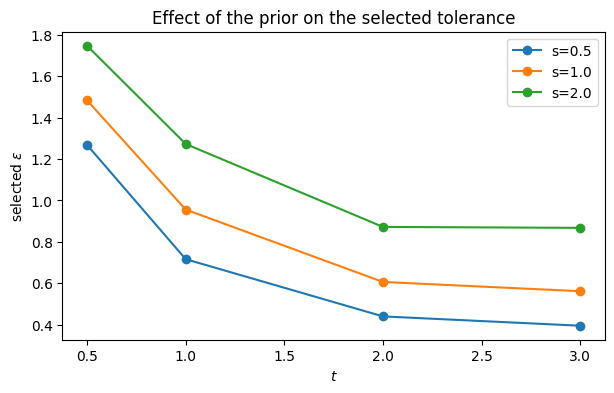

In [17]:
plt.figure(figsize=(7, 4))

for s_val in s_values:
    sub = prior_summary[prior_summary["s"] == s_val].sort_values("t")
    plt.plot(sub["t"], sub["epsilon"], marker="o", label=f"s={s_val}")

plt.xlabel(r"$t$")
plt.ylabel(r"selected $\varepsilon$")
plt.title(r"Effect of the prior on the selected tolerance")
plt.legend()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of the effect of the prior on the selected tolerance
</div>

This plot shows how the selected tolerance level $\varepsilon$ depends on the prior parameters $s$ and $t$, when using a quantile-based acceptance rule.

For a fixed acceptance quantile $q$, the tolerance $\varepsilon$ is defined as the empirical $q$-quantile of the Wasserstein distances. Therefore, $\varepsilon$ reflects how close the best simulated datasets are to the observed data.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect of t
</div>

We observe that $\varepsilon$ decreases significantly as $t$ increases. This indicates that the simulated datasets become closer to the observed data when the prior on $\log(\sigma^2)$ is more diffuse.

This behavior can be explained by the fact that the true value $\log(\sigma_0^2) \approx -2.41$ lies far from the prior mean $0$. When $t$ is small, the prior is too concentrated around $0$, and the algorithm rarely proposes values of $\sigma^2$ close to the true parameter. As a result, even the best simulated datasets remain relatively far from the observed data, leading to larger distances and thus larger values of $\varepsilon$.

As $t$ increases, the prior spreads out and begins to cover the region where the true parameter lies. This improves the quality of the best simulations, which are now closer to the observed data, and therefore reduces the selected tolerance $\varepsilon$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect of s
</div>

For a given value of $t$, increasing $s$ generally leads to larger values of $\varepsilon$. This reflects the fact that a wider prior on $\mu$ generates more dispersed parameter proposals, including many values far from the region supported by the data.

As a consequence, the overall quality of the simulated datasets deteriorates, and even the best simulations are less close to the observed data. This results in larger Wasserstein distances and thus larger tolerance levels.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation
</div>

This figure highlights an important and often overlooked aspect of Reject-ABC: the prior does not only influence the accepted parameters, but also indirectly affects the tolerance level when a quantile-based rule is used.

A poorly specified prior can lead to larger distances between simulated and observed data, which in turn increases the selected tolerance $\varepsilon$. This results in a less stringent acceptance criterion and potentially more biased posterior approximations.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

Overall, these results show that a well-chosen prior improves not only the efficiency of the algorithm, but also the quality of the ABC approximation by enabling smaller tolerance levels. This reinforces the idea that prior specification is a critical component of likelihood-free inference methods such as Reject-ABC.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Monte Carlo error assessment
</div> 

Finally, we assess the numerical variability of Reject-ABC by repeating the algorithm several times with independent random seeds.

This step is essential because a single ABC run may be affected by Monte Carlo randomness.  
Repeated runs allow us to evaluate the stability of the posterior summaries.

In [18]:
R = 20

mc_runs = repeated_reject_abc(
    y_obs=y_obs,
    L=L,
    N=20_000,
    s=1.0,
    t=2.0,
    q=0.01,
    R=R,
    base_seed=2026
)

mc_runs.round(4)

,run,epsilon,n_accepted,mu_median,mu_mean,sigma2_median,sigma2_mean,mean_distance_accepted
0,1,0.5965,200,-0.0037,-0.0057,0.0939,0.1038,0.3872
1,2,0.6623,200,-0.0106,-0.0058,0.0945,0.1093,0.4240
2,3,0.6030,200,-0.0038,-0.0047,0.1118,0.1120,0.4142
3,4,0.6497,200,-0.0042,-0.0068,0.1026,0.1123,0.4297
4,5,0.6013,200,-0.0108,-0.0127,0.1071,0.1161,0.3987
5,6,0.6328,200,-0.0017,-0.0082,0.0965,0.1104,0.4127
6,7,0.6158,200,-0.0005,-0.0046,0.1013,0.1143,0.4001
7,8,0.6229,200,-0.0088,-0.0093,0.1149,0.1188,0.4028
8,9,0.6102,200,-0.0083,-0.0073,0.0951,0.1083,0.4027
9,10,0.6206,200,0.0016,-0.0017,0.0905,0.1032,0.4178


In [19]:
mc_runs[["epsilon", "mu_median", "sigma2_median", "mean_distance_accepted"]].describe().round(4)

,epsilon,mu_median,sigma2_median,mean_distance_accepted
count,20.0000,20.0000,20.0000,20.0000
mean,0.6209,-0.0051,0.0994,0.4093
std,0.0195,0.0051,0.0084,0.0136
min,0.5844,-0.0150,0.0807,0.3872
25%,0.6119,-0.0090,0.0946,0.3998
50%,0.6185,-0.0051,0.0986,0.4082
75%,0.6306,-0.0015,0.1018,0.4180
max,0.6623,0.0043,0.1166,0.4387


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Monte Carlo error assessment — Interpretation
</div>

This table summarizes the variability of the Reject-ABC outputs across $R=20$ independent runs of the algorithm, each based on a different random seed. It provides a direct assessment of the **Monte Carlo error** induced by simulation.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Stability of the tolerance level
</div>

The selected tolerance $\varepsilon$ exhibits very limited variability, with a standard deviation of approximately $0.02$ around a mean value of $0.62$. 

This indicates that the **quantile-based selection of $\varepsilon$ is highly stable** across runs. The distribution of distances is therefore sufficiently regular so that the $q$-quantile is consistently estimated.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Stability of parameter estimates
</div>

The posterior medians of $\mu$ and $\sigma^2$ show very low variability:

- for $\mu$, the standard deviation is approximately $0.005$;
- for $\sigma^2$, the standard deviation is approximately $0.008$.

These values are small relative to the scale of the parameters, which indicates that the **ABC estimates are highly reproducible** across independent runs.

In particular, the median estimate of $\mu$ remains tightly concentrated around $0$, and the median estimate of $\sigma^2$ remains close to the true value $0.09$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Variability of the accepted distances
</div>

The mean distance of the accepted samples also shows limited dispersion (standard deviation $\approx 0.014$), confirming that the **quality of the accepted simulations is consistent across runs**.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation
</div>

Overall, the results indicate that the Monte Carlo variability induced by the Reject-ABC procedure is **moderate and well-controlled** for the chosen sample size $N=20{,}000$ and acceptance rate $q=1\%$.

This suggests that:

- the number of simulations is sufficiently large;
- the empirical summaries (medians, means) are reliable;
- and the conclusions drawn from a single run are not driven by randomness.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

This analysis validates the **numerical stability of the Reject-ABC implementation**. It shows that the estimation error is dominated by the ABC approximation itself (choice of $\varepsilon$ and prior), rather than by Monte Carlo noise.

In practice, this justifies relying on a single run of the algorithm for further analysis, while confirming that the results are statistically robust.

/tmp/ipykernel_96126/3622588505.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(mc_runs["mu_median"], labels=[r"$\mu$ median"])


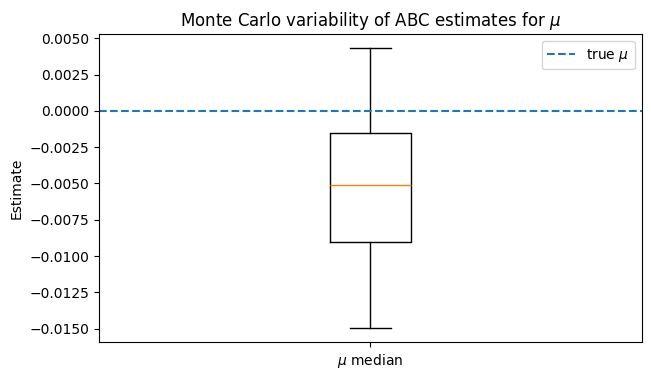

/tmp/ipykernel_96126/3622588505.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(mc_runs["sigma2_median"], labels=[r"$\sigma^2$ median"])


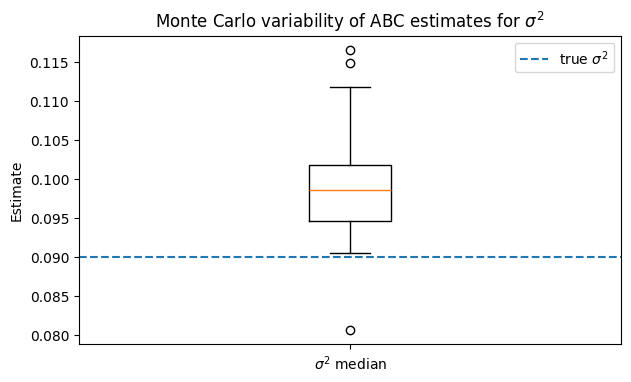

In [20]:
plt.figure(figsize=(7, 4))
plt.boxplot(mc_runs["mu_median"], labels=[r"$\mu$ median"])
plt.axhline(mu_true, linestyle="--", label=r"true $\mu$")
plt.ylabel("Estimate")
plt.title(r"Monte Carlo variability of ABC estimates for $\mu$")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.boxplot(mc_runs["sigma2_median"], labels=[r"$\sigma^2$ median"])
plt.axhline(sigma2_true, linestyle="--", label=r"true $\sigma^2$")
plt.ylabel("Estimate")
plt.title(r"Monte Carlo variability of ABC estimates for $\sigma^2$")
plt.legend()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Monte Carlo variability — Graphical interpretation
</div>

These boxplots provide a visual assessment of the Monte Carlo variability of the ABC median estimates across repeated runs of the algorithm.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Stability of the estimator for mu
</div>

The distribution of the median estimates for $\mu$ is tightly concentrated around the true value $\mu_0 = 0$, represented by the dashed line. 

The interquartile range is narrow, and the overall spread remains limited, indicating that the estimator exhibits **low Monte Carlo variability**. The slight negative shift observed in the median is consistent with the small bias previously identified, but remains negligible in magnitude.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Stability of the estimator for sigma^2
</div>

For $\sigma^2$, the variability is slightly larger, as reflected by a wider interquartile range and the presence of a few mild outliers. 

Nevertheless, the bulk of the estimates remains concentrated around the true value $\sigma_0^2 = 0.09$. This confirms that, although the variance parameter is more difficult to estimate, the ABC procedure still produces **stable and reliable estimates** across runs.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation
</div>

These graphical results reinforce the conclusions drawn from the numerical summary:

- the Monte Carlo error is **small relative to the scale of the parameters**;
- the variability across runs is limited;
- and the ABC estimates are **robust to the randomness of the simulation procedure**.

The slightly higher dispersion observed for $\sigma^2$ is consistent with the intrinsic difficulty of estimating scale parameters in this model.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Conclusion
</div>

Overall, these boxplots confirm that the Reject-ABC algorithm yields **numerically stable estimates**, and that the variability induced by Monte Carlo simulation remains well controlled under the chosen configuration.

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Conlusion Q-1 Reject-ABC
</div>

In this first part, we have implemented and analyzed the Reject-ABC algorithm in order to perform likelihood-free Bayesian inference for the parameters $\theta = (\mu, \sigma^2)$.

---

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Main findings
</div>

Our empirical study highlights several key results:

- **Accuracy of the estimates**:  
  The ABC posterior distributions are centered around the true parameter values. The posterior medians provide accurate point estimates, especially for $\mu$, while $\sigma^2$ is estimated with slightly higher uncertainty.

- **Effect of the tolerance parameter $\varepsilon$**:  
  The tolerance plays a central role in the quality of the approximation.  
  A small $\varepsilon$ leads to accurate but noisy estimates (few accepted samples), whereas a larger $\varepsilon$ increases stability at the cost of introducing bias.  
  This confirms the fundamental **bias–variance trade-off** inherent to ABC methods.

- **Influence of the prior**:  
  The prior distribution strongly impacts both the efficiency and the accuracy of the algorithm.  
  In particular, choosing an appropriate value for $t$ is crucial to ensure that the prior covers the true parameter region.  
  Moreover, we have shown that the prior indirectly affects the selected tolerance $\varepsilon$, and thus the overall quality of the approximation.

- **Monte Carlo stability**:  
  Repeated runs of the algorithm demonstrate that the Monte Carlo variability is well controlled.  
  The estimates are stable across independent simulations, confirming that the observed variability is mainly driven by the ABC approximation rather than by simulation noise.

---

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Limitations of Reject-ABC
</div>

Despite its simplicity and robustness, Reject-ABC suffers from an important limitation:

- it is **computationally inefficient**, especially when $\varepsilon$ is small, as the acceptance rate becomes extremely low;
- it requires a large number of simulations to obtain a sufficiently large accepted sample;
- and it does not scale well to more complex or higher-dimensional problems.

---

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Transition to Question 2
</div>

These limitations naturally motivate the introduction of more efficient algorithms.

In Question 2, we will replace the independent sampling mechanism of Reject-ABC by a **Markov Chain Monte Carlo (MCMC) approach**, leading to the MCMC-ABC algorithm.

The key idea is to construct a Markov chain that targets the same approximate posterior distribution $\pi_\varepsilon(\theta \mid y_{1:n})$, while exploring the parameter space more efficiently.

This approach allows us to:

- improve the **sampling efficiency**, especially for small values of $\varepsilon$;
- reduce the number of required simulations;
- and obtain a better approximation of the ABC posterior in practice.

This transition marks an important step from simple rejection-based methods to more advanced simulation techniques in likelihood-free inference.

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
2. MCMC-ABC
</div>

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
From independent sampling to Markovian exploration
</div>

In Part 1, we approximated the ABC posterior distribution

$$
\pi_\varepsilon(\theta \mid y_{1:n})
$$

using the Reject-ABC algorithm. This approach relies on **independent sampling from the prior**, followed by a selection step based on the similarity between simulated and observed data.

While effective, this strategy is computationally inefficient, especially when the tolerance parameter $\varepsilon$ is small. Most proposed parameters are rejected, leading to a significant waste of simulations.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
New idea: dependent sampling via MCMC
</div>

To overcome this limitation, we now adopt a different strategy.

Instead of generating independent parameter values, we construct a **Markov chain** whose successive states

$$
\theta^{(0)}, \theta^{(1)}, \theta^{(2)}, \dots
$$

are no longer independent, but **depend on the previous state**.

The key idea is to design this Markov chain such that its **stationary distribution** is the ABC posterior distribution:

$$
\pi_\varepsilon(\theta \mid y_{1:n}).
$$

Once the chain has converged, the generated samples can be interpreted as approximate draws from this posterior distribution.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Augmented formulation
</div>

To construct such a Markov chain, we work on an **augmented space**.

Instead of targeting directly $\pi_\varepsilon(\theta \mid y_{1:n})$, we introduce an auxiliary variable:

$$
z_{1:n} \sim p(\cdot \mid \theta),
$$

and define the augmented target distribution

$$
\pi_\varepsilon(\theta, z_{1:n} \mid y_{1:n})
\propto
\pi(\theta)\, p(z_{1:n} \mid \theta)\,
\mathbf{1}\left\{ W_1(y_{1:n}, z_{1:n}) \leq \varepsilon \right\}.
$$

This construction is crucial because:

- it allows us to **bypass the intractable likelihood**;
- and it provides a tractable structure for designing an MCMC algorithm.

Importantly, the marginal distribution of $\theta$ under this joint target is exactly

$$
\pi_\varepsilon(\theta \mid y_{1:n}),
$$

which is the same ABC posterior as in Part 1.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
How do we sample from this target?
</div>

We construct a Markov chain on the augmented space $(\theta, z_{1:n})$ using a **Metropolis–Hastings mechanism**.

At each iteration:

- we propose a new parameter $\theta'$ using a Gaussian random walk;
- we simulate a dataset $z'_{1:n} \sim p(\cdot \mid \theta')$;
- we accept or reject the proposal based on:
  - the ABC condition (distance ≤ $\varepsilon$),
  - and a Metropolis-Hastings correction involving the prior.

This results in a sequence of dependent samples:

$$
(\theta^{(0)}, z^{(0)}), (\theta^{(1)}, z^{(1)}), \dots
$$

which, after convergence, follow the joint ABC distribution.

By retaining only the $\theta$-component, we obtain a sample approximately distributed as

$$
\pi_\varepsilon(\theta \mid y_{1:n}).
$$

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Key intuition
</div>

The fundamental difference with Reject-ABC is the following:

- Reject-ABC explores the parameter space **globally but inefficiently**;
- MCMC-ABC explores it **locally but more efficiently**.

Once the chain reaches a region compatible with the data, it tends to remain in that region and explores it progressively.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Objective of this section
</div>

The goal of this part is therefore to:

- construct an MCMC algorithm targeting the ABC posterior;
- derive the acceptance probability rigorously;
- and study the practical behavior of this method compared to Reject-ABC.

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Acceptance rule — rigorous derivation
</div>

We construct a Metropolis--Hastings algorithm on the augmented space

$$
x = (\theta, z_{1:n}),
$$

targeting the joint ABC distribution

$$
\pi_\varepsilon(\theta, z_{1:n}\mid y_{1:n})
\propto
\pi(\theta)\,p(z_{1:n}\mid \theta)\,
\mathbf{1}\left\{W_1(y_{1:n},z_{1:n}) \leq \varepsilon\right\}.
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Proposal on the augmented space
</div>

From the current state $x=(\theta,z)$, we propose a new state $x'=(\theta',z')$ in two steps:

1. Propose a new parameter from a transition kernel:

$$
\theta' \sim q(\theta'\mid \theta).
$$

2. Simulate a synthetic dataset under the proposed parameter:

$$
z'_{1:n} \sim p(\cdot\mid \theta').
$$

Therefore, the proposal density on the augmented space is

$$
g(x'\mid x)
=
q(\theta'\mid\theta)\,p(z'_{1:n}\mid\theta').
$$

Similarly, the reverse proposal density is

$$
g(x\mid x')
=
q(\theta\mid\theta')\,p(z_{1:n}\mid\theta).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Metropolis--Hastings acceptance ratio
</div>

The Metropolis--Hastings acceptance probability is

$$
\alpha(x,x')
=
\min\left(
1,
\frac{
\pi_\varepsilon(x'\mid y_{1:n})\,g(x\mid x')
}{
\pi_\varepsilon(x\mid y_{1:n})\,g(x'\mid x)
}
\right).
$$

Substituting the ABC target and the proposal density gives

$$
\alpha
=
\min\left(
1,
\frac{
\pi(\theta')\,p(z'_{1:n}\mid\theta')\,
\mathbf{1}\left\{W_1(y_{1:n},z'_{1:n})\leq \varepsilon\right\}
q(\theta\mid\theta')\,p(z_{1:n}\mid\theta)
}{
\pi(\theta)\,p(z_{1:n}\mid\theta)\,
\mathbf{1}\left\{W_1(y_{1:n},z_{1:n})\leq \varepsilon\right\}
q(\theta'\mid\theta)\,p(z'_{1:n}\mid\theta')
}
\right).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
ABC screening step
</div>

The first part of the acceptance mechanism is the ABC condition.

If

$$
W_1(y_{1:n},z'_{1:n}) > \varepsilon,
$$

then the proposed state lies outside the ABC acceptance region and is rejected immediately.

If

$$
W_1(y_{1:n},z'_{1:n}) \leq \varepsilon,
$$

then the proposal satisfies the ABC condition and we apply the Metropolis--Hastings correction.

Since the chain is initialized from an accepted state, the current state satisfies

$$
W_1(y_{1:n},z_{1:n}) \leq \varepsilon.
$$

Therefore, on the event where the proposal passes the ABC screening, both indicator terms are equal to one.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Acceptance rule — simplified form
</div>

On the event

$$
W_1(y_{1:n},z'_{1:n}) \leq \varepsilon,
$$

the indicator terms are equal to one, and the likelihood terms cancel:

$$
p(z'_{1:n}\mid\theta')
\qquad \text{and} \qquad
p(z_{1:n}\mid\theta).
$$

Thus, the acceptance probability reduces to

$$
\alpha
=
\min\left(
1,
\frac{
\pi(\theta')\,q(\theta\mid\theta')
}{
\pi(\theta)\,q(\theta'\mid\theta)
}
\right).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Symmetric Gaussian random-walk proposal
</div>

In our implementation, we use a Gaussian random-walk proposal:

$$
\theta' = \theta + \tau \xi,
\qquad
\xi \sim \mathcal N(0,I).
$$

Equivalently, for the parameterization \(\theta=(\mu,\eta)\), with \(\eta=\log(\sigma^2)\),

$$
\mu' = \mu + \tau_\mu \xi_\mu,
\qquad
\eta' = \eta + \tau_\eta \xi_\eta,
\qquad
\xi_\mu,\xi_\eta \sim \mathcal N(0,1).
$$

This proposal is symmetric, meaning that

$$
q(\theta'\mid\theta)
=
q(\theta\mid\theta').
$$

Therefore, the proposal terms cancel, and the acceptance probability becomes

$$
\alpha
=
\min\left(
1,
\frac{\pi(\theta')}{\pi(\theta)}
\right).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Log-scale implementation
</div>

In practice, it is more stable to compute the acceptance probability on the log-scale.

With the prior

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\eta=\log(\sigma^2)\sim \mathcal N(0,t^2),
$$

the log-prior is

$$
\log \pi(\mu,\eta)
=
-\frac{1}{2}\frac{\mu^2}{s^2}
-\frac{1}{2}\frac{\eta^2}{t^2}
\quad
\text{up to an additive constant}.
$$

Thus, after the ABC condition has been satisfied, we accept the proposal if

$$
\log U
\leq
\log \pi(\theta')-\log \pi(\theta),
\qquad
U\sim \mathcal U(0,1).
$$

If the proposal is accepted, we set

$$
\theta^{(k+1)}=\theta',
$$

otherwise we keep the current value:

$$
\theta^{(k+1)}=\theta^{(k)}.
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation
</div>

The acceptance mechanism combines two components:

- an **ABC screening step**, which ensures that only parameters generating realistic synthetic datasets are considered;
- a **Metropolis--Hastings correction**, which ensures that the Markov chain has the correct invariant distribution.

The key point is that the intractable likelihood cancels out of the acceptance ratio. This cancellation is what makes MCMC-ABC feasible in a likelihood-free setting.

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Computational Framework for MCMC-ABC
</div>

We now define the computational tools required to implement the MCMC-ABC sampler.

We reuse the simulator introduced in Part 1. Since MCMC-ABC proposes one parameter value at a time, we also define a single-sample Wasserstein distance, a log-prior function, and the main MCMC-ABC sampler.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Wasserstein distance for single-sample comparisons
</div> 

In Part 1, we used a vectorized implementation of the Wasserstein distance to compare the observed dataset with many simulated datasets simultaneously.

In the MCMC-ABC framework, proposals are generated sequentially, one parameter at a time. As a result, we only need to compare the observed dataset with a single simulated dataset at each iteration.

The following function computes the empirical one-dimensional Wasserstein distance between two samples of equal size. It is based on sorting both samples and computing the average absolute difference between their order statistics.

In [21]:
def wasserstein_1d(y, z):
    """
    Computes the empirical W1 distance between two one-dimensional samples.
    Both samples must have the same length.
    """
    y_sorted = np.sort(y)
    z_sorted = np.sort(z)
    return np.mean(np.abs(y_sorted - z_sorted))

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Log-prior computation for Metropolis-Hastings correction
</div> 

In the MCMC-ABC algorithm, the Metropolis-Hastings step requires computing the ratio of prior densities between the proposed parameter and the current one.

To improve numerical stability and simplify the computation, it is standard to work on the logarithmic scale. Since the acceptance probability only depends on the ratio of prior densities, the log-prior can be computed up to an additive constant.

We use the same prior specification as in Part 1, with the reparameterization

$$
\theta = (\mu, \eta), \quad \text{where} \quad \eta = \log(\sigma^2).
$$

The prior distributions are given by

$$
\mu \sim \mathcal{N}(0, s^2),
\qquad
\eta \sim \mathcal{N}(0, t^2).
$$

The following function returns the log-prior value associated with a parameter pair $(\mu, \eta)$, ignoring constant terms that cancel out in the Metropolis-Hastings ratio.

In [22]:
def log_prior_mu_eta(mu, eta, s, t):
    return -0.5 * (mu**2 / s**2) - 0.5 * (eta**2 / t**2)

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
MCMC-ABC sampler: full implementation
</div> 

We now implement the full MCMC-ABC sampler.

The algorithm is structured in two main stages:

- an initialization phase, which searches for a first parameter value satisfying the ABC constraint;
- a Markov chain phase, which explores the ABC posterior distribution using local random-walk proposals combined with a Metropolis-Hastings correction.


In [23]:
def mcmc_abc(
    y_obs,
    L,
    K,
    s,
    t,
    epsilon,
    tau_mu,
    tau_eta,
    theta0=None,
    max_init_tries=100_000,
    rng=None
):
    if rng is None:
        raise ValueError("A random generator rng must be provided.")

    n = len(y_obs)

    # Initial parameter value
    if theta0 is None:
        mu_curr = rng.normal(0.0, s)
        eta_curr = rng.normal(0.0, t)
    else:
        mu_curr, eta_curr = theta0

    rows = []

    # --------------------------------------------------
    # Initialization search: find a state satisfying ABC
    # --------------------------------------------------
    n_init = 0

    while True:
        eta_curr = np.clip(eta_curr, -10, 3)
        sigma2_curr = np.exp(eta_curr)
        sigma_curr = np.sqrt(sigma2_curr)

        z_curr = simulate_sum_lognormal(
            n=n,
            L=L,
            mu=mu_curr,
            sigma=sigma_curr,
            rng=rng
        )

        d_curr = wasserstein_1d(y_obs, z_curr)
        abc_valid_curr = d_curr <= epsilon

        rows.append({
            "iter": len(rows),
            "phase": "initialization",
            "mu": mu_curr,
            "eta": eta_curr,
            "sigma2": sigma2_curr,
            "sigma": sigma_curr,
            "distance": d_curr,
            "accepted_move": False,
            "mu_before": np.nan,
            "eta_before": np.nan,
            "sigma2_before": np.nan,
            "mu_prop": np.nan,
            "eta_prop": np.nan,
            "sigma2_prop": np.nan,
            "distance_prop": np.nan,
            "abc_valid": abc_valid_curr
        })

        if abc_valid_curr:
            break

        n_init += 1
        if n_init > max_init_tries:
            raise RuntimeError(
                "No valid initial state found. "
                "Try increasing epsilon or max_init_tries."
            )

        # Local random-walk search for an ABC-valid initial state
        mu_curr += tau_mu * rng.normal()
        eta_curr += tau_eta * rng.normal()

    # --------------------------------------------------
    # MCMC-ABC phase
    # --------------------------------------------------
    n_accept = 0

    for k in range(K):
        mu_before = mu_curr
        eta_before = eta_curr
        sigma2_before = np.exp(eta_before)

        # Gaussian random-walk proposal
        mu_prop = mu_curr + tau_mu * rng.normal()
        eta_prop = eta_curr + tau_eta * rng.normal()
        eta_prop = np.clip(eta_prop, -10, 3)

        sigma2_prop = np.exp(eta_prop)
        sigma_prop = np.sqrt(sigma2_prop)

        # Simulate synthetic data under proposed parameter
        z_prop = simulate_sum_lognormal(
            n=n,
            L=L,
            mu=mu_prop,
            sigma=sigma_prop,
            rng=rng
        )

        d_prop = wasserstein_1d(y_obs, z_prop)
        abc_valid = d_prop <= epsilon

        accepted = False

        # ABC screening + MH prior correction
        if abc_valid:
            log_alpha = (
                log_prior_mu_eta(mu_prop, eta_prop, s, t)
                - log_prior_mu_eta(mu_curr, eta_curr, s, t)
            )

            if np.log(rng.uniform()) <= min(0.0, log_alpha):
                mu_curr = mu_prop
                eta_curr = eta_prop
                d_curr = d_prop
                accepted = True
                n_accept += 1

        rows.append({
            "iter": len(rows),
            "phase": "mcmc",
            "mu": mu_curr,
            "eta": eta_curr,
            "sigma2": np.exp(eta_curr),
            "sigma": np.sqrt(np.exp(eta_curr)),
            "distance": d_curr,
            "accepted_move": accepted,
            "mu_before": mu_before,
            "eta_before": eta_before,
            "sigma2_before": sigma2_before,
            "mu_prop": mu_prop,
            "eta_prop": eta_prop,
            "sigma2_prop": sigma2_prop,
            "distance_prop": d_prop,
            "abc_valid": abc_valid
        })

    chain = pd.DataFrame(rows)
    acceptance_rate = n_accept / K

    return chain, acceptance_rate


<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Initialization phase: entering the ABC region
</div>

The MCMC-ABC algorithm requires starting from a parameter value that satisfies the ABC condition

$$
W_1(y_{1:n}, z_{1:n}) \leq \varepsilon.
$$

However, an arbitrary initial value does not necessarily satisfy this constraint. Therefore, we perform an initialization search:

- we simulate data under the current parameter;
- we compute the Wasserstein distance to the observed dataset;
- we update the parameter using a local random-walk proposal;
- we repeat until the ABC condition is satisfied.

This phase ensures that the Markov chain starts inside the support of the ABC posterior.

Importantly, this phase is not part of the posterior sample.


---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
MCMC phase: local exploration of the ABC posterior
</div>

Once a valid initial state has been found, the algorithm enters the MCMC phase.

At each iteration:

1. A new parameter is proposed using a Gaussian random walk;
2. A synthetic dataset is simulated under the proposed parameter;
3. The ABC condition is checked;
4. If the condition is satisfied, a Metropolis-Hastings correction is applied using the prior ratio.

This combination of ABC screening and Metropolis-Hastings correction ensures that the Markov chain targets the ABC posterior distribution.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Output: chain storage and acceptance rate
</div>

All iterations (initialization and MCMC phases) are stored in a structured DataFrame. This allows detailed diagnostics such as trace plots, acceptance analysis, and visualization of proposals.

We also compute the MCMC acceptance rate, excluding the initialization phase.

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Empirical Study of MCMC-ABC Performance
</div>

We now investigate the empirical behavior of the MCMC-ABC algorithm.

The objective of this section is to:

- assess the convergence of the chain,
- analyze the initialization phase,
- evaluate the acceptance mechanism,
- and study the structure of the posterior sample.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Baseline run
</div> 

We begin the empirical analysis with a baseline implementation of the MCMC-ABC algorithm.

The goal of this first run is to establish a reference configuration that will be used throughout the rest of the analysis. In particular, we use the same prior parameters $(s,t)$ and the same tolerance level $\varepsilon$ as in Question 1, in order to ensure comparability between Reject-ABC and MCMC-ABC.

The number of MCMC iterations is set to $K = 20{,}000$, which allows the chain to explore the parameter space over a sufficiently long horizon. The proposal standard deviations $(\tau_\mu, \tau_\eta)$ are chosen to produce local moves, ensuring a reasonable balance between acceptance rate and exploration.

Importantly, the chain is deliberately initialized far from the true parameter values. This allows us to explicitly observe the behavior of the initialization phase, during which the algorithm searches for a parameter satisfying the ABC constraint. It also provides insight into how quickly the chain is able to enter the ABC-compatible region.

Finally, a fixed random seed is used to ensure reproducibility of the results.

The output of the algorithm consists of:

- the full MCMC chain, including both the initialization phase and the MCMC phase;
- the acceptance rate computed over the MCMC iterations only.

These outputs will be used in the following sections to analyze convergence, stability, and posterior structure.

In [24]:
# -----------------------------
# Baseline MCMC-ABC run
# -----------------------------

# Settings (same as Q1 for comparability)
K = 20_000
tau_mu = 0.02
tau_eta = 0.20

# Starting point deliberately far
mu_start = -0.8
sigma2_start = 0.8
eta_start = np.log(sigma2_start)

theta_start_far = (mu_start, eta_start)

# Random generator
rng_mcmc = np.random.default_rng(123)

# Run MCMC-ABC
mcmc_chain, mcmc_acceptance_rate = mcmc_abc(
    y_obs=y_obs,
    L=L,
    K=K,
    s=s,
    t=t,
    epsilon=epsilon_used,
    tau_mu=tau_mu,
    tau_eta=tau_eta,
    theta0=theta_start_far,
    rng=rng_mcmc
)

print(f"MCMC acceptance rate (excluding init): {mcmc_acceptance_rate:.4f}")
print(f"Total iterations (including init): {len(mcmc_chain)}")

MCMC acceptance rate (excluding init): 0.7089
Total iterations (including init): 21198


<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Initialization / acceptance rate
</div> 

We now summarize the main diagnostics of the MCMC-ABC run.

The chain contains two distinct phases:

- the **initialization phase**, during which the algorithm searches for a first parameter value satisfying the ABC condition;
- the **MCMC phase**, during which the Markov chain explores the ABC posterior by local proposals.

We compute the number of initialization trials, the number of MCMC iterations, and the number of accepted MCMC moves.

The acceptance rate is an important diagnostic because it indicates how often proposed moves are accepted after applying both:

- the ABC screening condition;
- the Metropolis-Hastings correction.

A very low acceptance rate would suggest that the proposal steps are too large or that the tolerance level is too strict.  
A very high acceptance rate may indicate that the proposal steps are too small, leading to slow exploration of the posterior distribution.

This diagnostic therefore helps assess whether the proposal scales $(\tau_\mu,\tau_\eta)$ are reasonably calibrated.


In [25]:
# -----------------------------
# Initialization diagnostics
# -----------------------------

n_init_trials = (mcmc_chain["phase"] == "initialization").sum()
n_mcmc_steps = (mcmc_chain["phase"] == "mcmc").sum()
n_accepted_moves = mcmc_chain["accepted_move"].sum()

overall_acceptance_rate = n_accepted_moves / len(mcmc_chain)

print("Initialization trials:", n_init_trials)
print("MCMC iterations:", n_mcmc_steps)
print("Accepted moves (MCMC only):", n_accepted_moves)
print("Overall acceptance rate:", overall_acceptance_rate)

Initialization trials: 1198
MCMC iterations: 20000
Accepted moves (MCMC only): 14178
Overall acceptance rate: 0.6688366827059157


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of initialization and acceptance diagnostics
</div>

The results provide a clear picture of the behavior of the MCMC-ABC algorithm in this baseline configuration.

First, the number of initialization trials is equal to $1198$. This reflects the cost of entering the ABC-compatible region when starting from a deliberately poor initial value. The algorithm initially explores the parameter space using local random-walk proposals until it finds a parameter $\theta$ such that

$$
W_1(y_{1:n}, z_{1:n}) \leq \varepsilon.
$$

Although this initialization phase is not negligible, it remains moderate relative to the total number of iterations, and therefore does not dominate the overall computational cost.

Once the chain has entered the ABC region, it performs $20{,}000$ MCMC iterations. Among these, $14{,}178$ proposals are accepted, leading to an acceptance rate of approximately $0.67$.

This relatively high acceptance rate indicates that the proposal mechanism is well calibrated:

- the local random-walk steps are small enough to remain within the ABC-compatible region with high probability;
- the Metropolis-Hastings correction rejects only a limited number of proposals.

From an algorithmic perspective, this suggests that once initialized, the chain efficiently explores the posterior region by making local moves around plausible parameter values.

However, such a high acceptance rate may also indicate that the proposal steps $(\tau_\mu, \tau_\eta)$ are somewhat conservative. While this ensures stability, it may slow down the exploration of the parameter space by limiting the magnitude of the moves.

Overall, these diagnostics show that:

- the initialization phase successfully identifies a valid starting point at a reasonable cost;
- the MCMC phase exhibits a stable and efficient behavior;
- and the chosen proposal scales provide a good compromise between acceptance and exploration.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Trace plots
</div> 

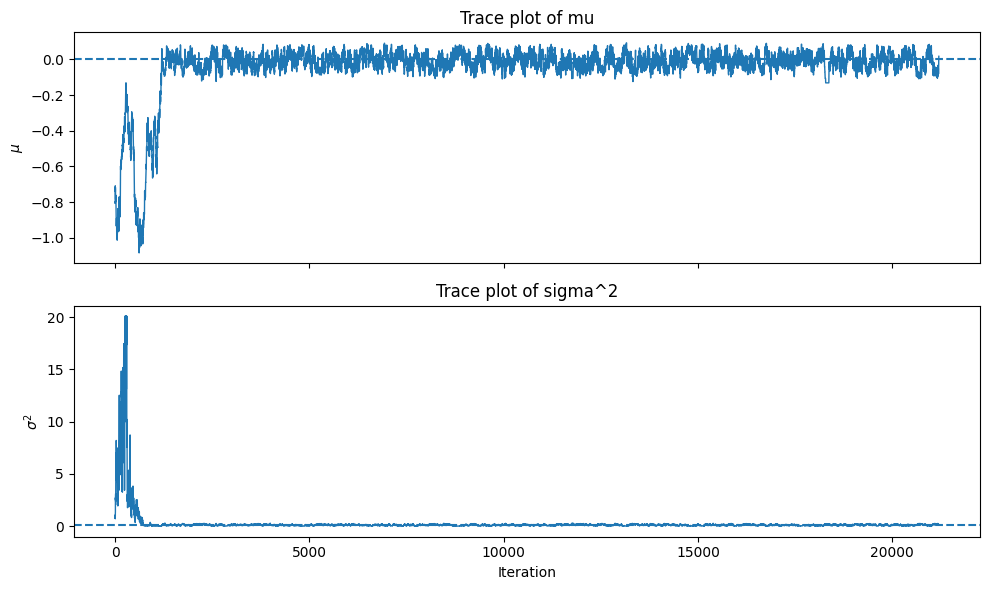

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(mcmc_chain["iter"], mcmc_chain["mu"], linewidth=1)
axes[0].axhline(mu_true, linestyle="--")
axes[0].set_ylabel(r"$\mu$")
axes[0].set_title("Trace plot of mu")

axes[1].plot(mcmc_chain["iter"], mcmc_chain["sigma2"], linewidth=1)
axes[1].axhline(sigma2_true, linestyle="--")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_title("Trace plot of sigma^2")

plt.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of trace plots
</div>

The trace plots provide a detailed view of the full trajectory of the MCMC-ABC algorithm, combining both the initialization phase and the subsequent MCMC exploration.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Behavior of the chain for mu
</div>

The trajectory of $\mu$ clearly reveals two distinct regimes.

In the first iterations, the chain starts from a value far below the true parameter and exhibits large and irregular fluctuations. This corresponds to the **initialization phase**, during which the algorithm performs a local random-walk search in order to find a parameter satisfying the ABC constraint.

After this transient phase, the chain rapidly transitions toward a region centered around the true value
$$
\mu_0 = 0.
$$

From that point onward, the trajectory stabilizes and fluctuates around this value without any visible long-term drift. This behavior is characteristic of a Markov chain that has reached its **stationary regime**, suggesting that the algorithm is effectively exploring the posterior distribution.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Behavior of the chain for sigma^2
</div>

The trace plot for $\sigma^2$ exhibits an even more pronounced contrast between the initialization and MCMC phases.

At the beginning of the run, the chain takes extremely large values and shows strong variability. This reflects the fact that the initial parameter lies far outside the ABC-compatible region, leading to unstable and highly dispersed simulated values.

Once the ABC condition is satisfied, the chain rapidly moves into a much smaller region and begins to fluctuate around the true parameter
$$
\sigma_0^2 = 0.09.
$$

The variability remains noticeably larger than for $\mu$, which is consistent with previous observations: the variance parameter is intrinsically harder to estimate and exhibits higher posterior uncertainty.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global interpretation of the trace plots
</div>

Taken together, these trace plots highlight three fundamental features of the MCMC-ABC algorithm:

- a clear **initialization phase**, characterized by large movements and unstable parameter values;
- a **rapid transition** toward the ABC-compatible region once a valid parameter is found;
- a **stable MCMC phase**, where the chain fluctuates around the true parameters and explores the posterior distribution.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Implications for inference
</div>

These results are fully consistent with the theoretical construction of the algorithm.

The early iterations should be interpreted as a **transient phase**, whose sole purpose is to locate the ABC-compatible region. They do not reflect the target posterior distribution and must therefore be discarded when performing inference.

Only the stabilized part of the chain—after this initial transition—can be considered as approximately drawn from the ABC posterior distribution.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Burn-in selection 
</div> 

Before analyzing the posterior sample, we must remove the initial part of the MCMC chain corresponding to the **transient phase**.

As highlighted in the trace plots, the early iterations of the chain are influenced by the initialization process and do not yet reflect the stationary distribution. Including these observations would bias the posterior summaries and distort the interpretation.

We therefore proceed in two steps:

- first, we isolate the **MCMC phase only**, excluding the initialization phase;
- second, we discard a fixed number of initial MCMC iterations, referred to as the **burn-in period**.

In this experiment, we set the burn-in length to $3000$ iterations. This choice is deliberately conservative, ensuring that the chain has fully entered its stationary regime before we begin inference.

The remaining observations, stored in `post_chain`, constitute the **post-burn-in sample**, which will be used for all subsequent analyses (trace plots, posterior summaries, and graphical diagnostics).

Finally, we report the size of the retained sample to verify that a sufficiently large number of iterations remains after burn-in.

In [27]:

# -----------------------------
# Burn-in selection
# -----------------------------

mcmc_only = mcmc_chain[mcmc_chain["phase"] == "mcmc"].copy().reset_index(drop=True)

burnin_idx = 3000

post_chain = mcmc_only.iloc[burnin_idx:].copy()

print("Post burn-in sample size:", len(post_chain))

Post burn-in sample size: 17000


<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Post-burn-in trace plots
</div> 



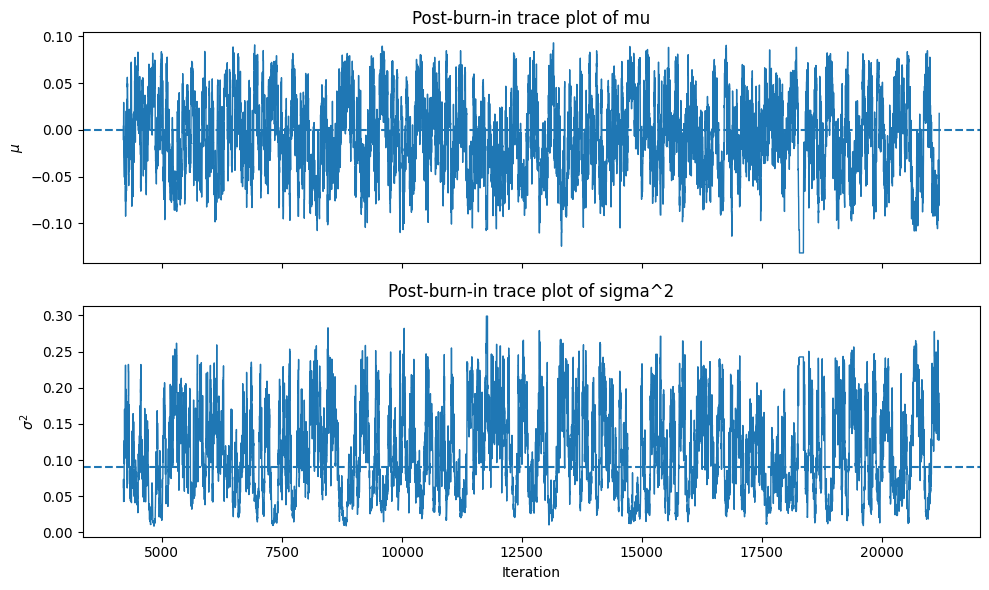

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(post_chain["iter"], post_chain["mu"], linewidth=1)
axes[0].axhline(mu_true, linestyle="--")
axes[0].set_ylabel(r"$\mu$")
axes[0].set_title("Post-burn-in trace plot of mu")

axes[1].plot(post_chain["iter"], post_chain["sigma2"], linewidth=1)
axes[1].axhline(sigma2_true, linestyle="--")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_title("Post-burn-in trace plot of sigma^2")

plt.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of post-burn-in trace plots
</div>

The trace plots now display only the **post-burn-in phase** of the MCMC-ABC chain, i.e., after removing the transient initialization and early MCMC iterations.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Behavior of the chain for mu
</div>

The trajectory of $\mu$ exhibits stable fluctuations around the true value
$$
\mu_0 = 0.
$$

The chain shows no visible trend, drift, or structural break over time. Instead, it oscillates within a relatively narrow band, indicating that the algorithm is effectively exploring a stable region of the posterior distribution.

The variability remains moderate and consistent across iterations, which suggests good mixing properties for this parameter.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Behavior of the chain for sigma^2
</div>

For $\sigma^2$, the chain also fluctuates around the true value
$$
\sigma_0^2 = 0.09,
$$

but with noticeably larger variability.

The trajectory is more irregular and exhibits wider excursions compared to $\mu$, reflecting the higher uncertainty associated with the variance parameter. This behavior is consistent with previous observations from Reject-ABC and from the full trace plots.

Despite this increased variability, the chain repeatedly returns to values close to the true parameter, and remains confined within a plausible posterior region.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global assessment of convergence
</div>

These post-burn-in trace plots provide strong evidence that the chain has reached a **stationary regime**:

- there is no remaining transient behavior;
- the fluctuations appear stable over time;
- both parameters are explored without systematic drift.

This suggests that the retained samples can be interpreted as approximate draws from the ABC posterior distribution.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Implications for inference
</div>

The removal of the burn-in phase was therefore appropriate, as it isolates the part of the chain that reflects the target distribution.

The post-burn-in sample can now be safely used for:

- posterior summaries (means, medians, variances);
- graphical diagnostics;
- and comparison with Reject-ABC.

Overall, these results confirm that the MCMC-ABC algorithm produces a stable and reliable approximation of the posterior distribution once the transient phase has been discarded.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Post-burn-in cloud
</div> 

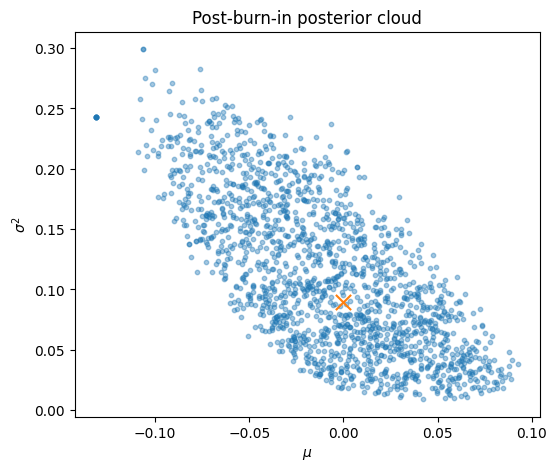

In [29]:

plt.figure(figsize=(6, 5))

plt.scatter(
    post_chain["mu"].iloc[::10],
    post_chain["sigma2"].iloc[::10],
    s=10,
    alpha=0.4
)

plt.scatter(mu_true, sigma2_true, marker="x", s=120)

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma^2$")
plt.title("Post-burn-in posterior cloud")

plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of post-burn-in posterior cloud
</div>

The scatter plot represents the **post-burn-in sample** of the MCMC-ABC chain in the parameter space
$$
(\mu, \sigma^2).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global structure of the posterior
</div>

The cloud exhibits a clear **elongated shape**, indicating that the posterior distribution is not isotropic but structured along a specific direction.

In particular, we observe a pronounced **negative dependence** between $\mu$ and $\sigma^2$:

- lower values of $\mu$ tend to be associated with higher values of $\sigma^2$;
- higher values of $\mu$ tend to be associated with lower values of $\sigma^2$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation of the dependence structure
</div>

This pattern is a direct consequence of the model structure. Recall that the mean of the observations satisfies

$$
\mathbb{E}[Y_i] = L \exp\left(\mu + \frac{\sigma^2}{2}\right).
$$

As a result, different combinations of $(\mu, \sigma^2)$ can produce similar expected values.

In particular, an increase in $\sigma^2$ can be compensated by a decrease in $\mu$, and vice versa. The ABC algorithm therefore tends to accept parameter pairs lying along curves where

$$
\mu + \frac{\sigma^2}{2} \approx \text{constant}.
$$

This induces the observed trade-off between the two parameters.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Location of the true parameter
</div>

The true parameter value (highlighted on the plot) lies well inside the posterior cloud.

This confirms that the MCMC-ABC algorithm successfully identifies a region of the parameter space that is consistent with the observed data.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Comparison with Reject-ABC
</div>

The structure of the cloud is fully consistent with what was observed in Question 1 using Reject-ABC:

- similar negative dependence between $\mu$ and $\sigma^2$;
- similar location and spread of the posterior mass.

This provides additional evidence that both methods target the same ABC posterior distribution.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Implications for inference
</div>

Overall, this visualization highlights two key aspects of the inference problem:

- the posterior distribution is **well localized** around the true parameter;
- however, it exhibits a **strong dependence structure**, reflecting partial identifiability of the parameters.

This confirms that MCMC-ABC not only recovers the correct region of the parameter space, but also captures the intrinsic geometry of the posterior distribution.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Initialization + early MCMC + cloud (3 panels)
</div> 

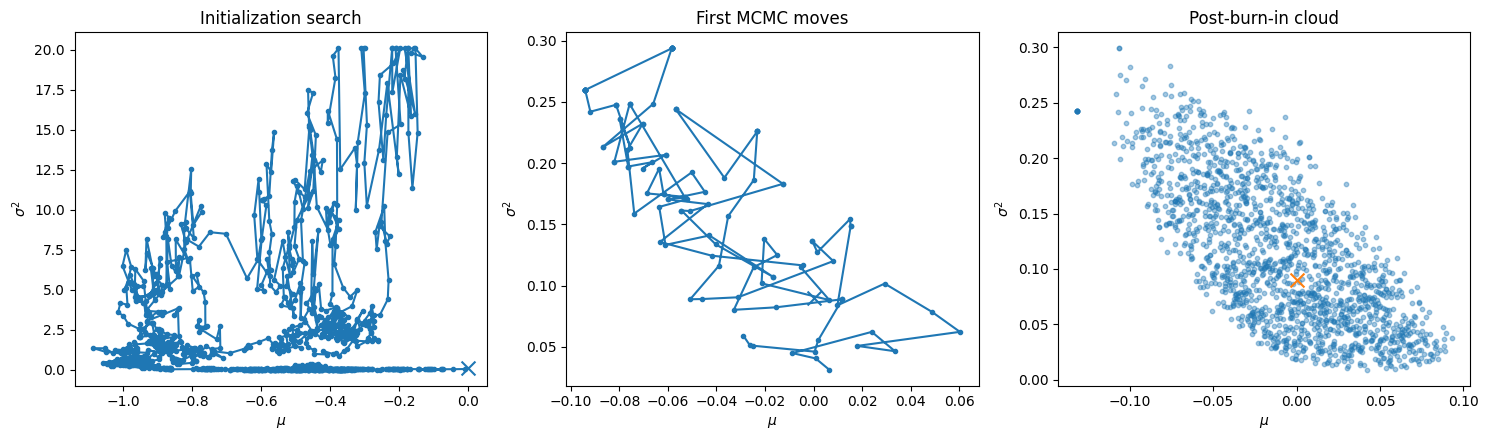

In [30]:
init_chain = mcmc_chain[mcmc_chain["phase"] == "initialization"].copy().reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Initialization
axes[0].plot(init_chain["mu"], init_chain["sigma2"], marker="o", markersize=3)
axes[0].scatter(mu_true, sigma2_true, marker="x", s=100)
axes[0].set_title("Initialization search")

# First MCMC steps
first_mcmc = mcmc_only.iloc[:120]
axes[1].plot(first_mcmc["mu"], first_mcmc["sigma2"], marker="o", markersize=3)
axes[1].scatter(mu_true, sigma2_true, marker="x", s=100)
axes[1].set_title("First MCMC moves")

# Posterior cloud
axes[2].scatter(post_chain["mu"].iloc[::10], post_chain["sigma2"].iloc[::10], s=10, alpha=0.4)
axes[2].scatter(mu_true, sigma2_true, marker="x", s=100)
axes[2].set_title("Post-burn-in cloud")

for ax in axes:
    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel(r"$\sigma^2$")

plt.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of initialization, early MCMC moves, and posterior cloud
</div>

The three panels provide a comprehensive visualization of the different stages of the MCMC-ABC algorithm in the parameter space
$$
(\mu, \sigma^2).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Initialization phase (left panel)
</div>

The left panel illustrates the **initialization search**, starting from a deliberately poor initial value.

The trajectory is highly irregular and spans a wide region of the parameter space, with very large values of $\sigma^2$. This reflects the exploratory nature of this phase: the algorithm performs a local random walk until it finds a parameter satisfying the ABC constraint

$$
W_1(y_{1:n}, z_{1:n}) \leq \varepsilon.
$$

At this stage, the algorithm is not sampling from the posterior distribution, but merely attempting to **enter the ABC-compatible region**. The instability and large excursions are therefore expected.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Early MCMC phase (middle panel)
</div>

The middle panel shows the **first iterations of the MCMC phase**, starting from the first accepted parameter.

Compared to the initialization phase, the trajectory is much more localized. The chain begins to move within a restricted region of the parameter space, reflecting the fact that it has already reached a plausible zone.

The moves are now governed by the **Gaussian random-walk proposal**, leading to local transitions between nearby parameter values. This marks the beginning of the actual posterior exploration.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Post-burn-in posterior cloud (right panel)
</div>

The right panel displays the **post-burn-in sample**, which represents the stabilized phase of the algorithm.

The cloud exhibits a clear elongated structure, revealing a strong **negative dependence** between $\mu$ and $\sigma^2$. As previously discussed, this pattern arises from the model structure, where different parameter combinations can produce similar expected values.

The true parameter lies well inside this cloud, confirming that the algorithm successfully identifies a region consistent with the observed data.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global interpretation
</div>

Taken together, the three panels highlight the full dynamics of the MCMC-ABC algorithm:

- an initial **exploratory phase**, aimed at finding a valid starting point;
- a transition to **local exploration**, once the ABC condition is satisfied;
- and a final **stationary regime**, where the chain samples from the approximate posterior distribution.

This progression illustrates how MCMC-ABC combines global exploration (during initialization) and local refinement (during the MCMC phase), ultimately producing a coherent approximation of the ABC posterior.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Accepted vs rejected proposals
</div> 

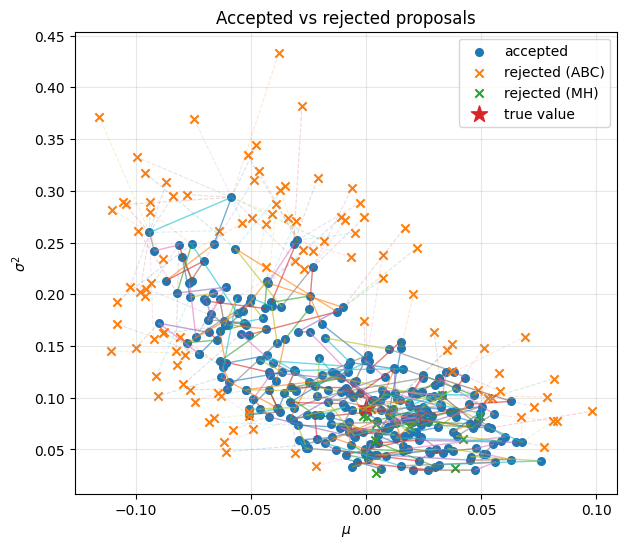

In [31]:
first_moves = mcmc_only.iloc[:400]

acc = first_moves[first_moves["accepted_move"]]
rej_abc = first_moves[~first_moves["abc_valid"]]
rej_mh = first_moves[(first_moves["abc_valid"]) & (~first_moves["accepted_move"])]

plt.figure(figsize=(7, 6))

# segments
for _, row in first_moves.iterrows():
    if row["accepted_move"]:
        plt.plot([row["mu_before"], row["mu_prop"]],
                 [row["sigma2_before"], row["sigma2_prop"]],
                 linewidth=1.0, alpha=0.6)
    else:
        plt.plot([row["mu_before"], row["mu_prop"]],
                 [row["sigma2_before"], row["sigma2_prop"]],
                 linewidth=0.8, alpha=0.2, linestyle="--")

# points
plt.scatter(acc["mu_prop"], acc["sigma2_prop"], s=30, label="accepted")
plt.scatter(rej_abc["mu_prop"], rej_abc["sigma2_prop"], marker="x", label="rejected (ABC)")
plt.scatter(rej_mh["mu_prop"], rej_mh["sigma2_prop"], marker="x", label="rejected (MH)")

plt.scatter(mu_true, sigma2_true, marker="*", s=150, label="true value")

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma^2$")
plt.title("Accepted vs rejected proposals")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of accepted vs rejected proposals
</div>

This plot provides a detailed view of the **proposal mechanism** in the early MCMC iterations, distinguishing between accepted and rejected moves in the parameter space
$$
(\mu, \sigma^2).
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Structure of accepted proposals
</div>

The blue points represent the **accepted proposals**, which form the actual trajectory of the Markov chain.

These points are concentrated in a relatively compact region of the parameter space, corresponding to the **ABC-compatible region**. The accepted moves follow a structured path, gradually exploring this region through local transitions.

This confirms that once the chain has entered a plausible region, it continues to explore it efficiently using the random-walk proposal.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Rejections due to the ABC constraint
</div>

The orange crosses correspond to proposals rejected at the **ABC stage**, i.e., those for which

$$
W_1(y_{1:n}, z_{1:n}) > \varepsilon.
$$

These rejected points are more widely dispersed and often lie outside the main cloud of accepted values. This indicates that many proposed parameters generate simulated datasets that are too far from the observed data.

This highlights the role of the ABC filter as a **geometric constraint** that restricts the exploration to a subset of the parameter space.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Rejections due to the Metropolis–Hastings step
</div>

The green crosses represent proposals that satisfy the ABC condition but are rejected by the **Metropolis–Hastings correction**.

These points lie within or near the accepted region, showing that even among plausible parameters, not all proposals are accepted. The MH step therefore ensures that the chain correctly targets the ABC posterior distribution by adjusting for the prior.

In this plot, the number of such rejections is relatively small, indicating that the main source of rejection is the ABC constraint rather than the MH step.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Role of the proposal mechanism
</div>

The dashed segments connecting points illustrate the proposed moves from the current state to candidate values.

Accepted moves tend to be short and remain within the high-probability region, while rejected moves often correspond to proposals that jump outside this region.

This reflects the local nature of the Gaussian random-walk proposal, which generates candidate parameters in the neighborhood of the current state.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global interpretation
</div>

Overall, this plot makes the MCMC-ABC mechanism explicit:

- the ABC constraint defines a **feasible region** in the parameter space;
- the random-walk proposal generates local candidates around the current state;
- the Metropolis–Hastings step refines the selection among feasible proposals.

The true parameter lies within the accepted region, confirming that the algorithm is correctly exploring the relevant part of the parameter space.

This visualization provides strong intuition on how MCMC-ABC combines **geometric filtering (ABC)** and **probabilistic correction (MH)** to construct a valid posterior sampler.

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Comparison with Reject-ABC
</div>

We now compare MCMC-ABC with Reject-ABC under the same ABC specification: same prior, same tolerance level, and same Wasserstein distance.

Both methods target the same ABC posterior distribution. The goal is therefore to compare:

- posterior summaries;
- marginal posterior distributions;
- joint posterior clouds;
- computational efficiency;
- robustness when $\varepsilon$ is smaller;
- robustness when the prior is more diffuse.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Prepare comparable samples
</div> 

Before comparing Reject-ABC and MCMC-ABC, we need to construct **comparable samples** from both methods.

Although both algorithms target the same ABC posterior distribution, their outputs differ in nature:

- Reject-ABC produces a relatively small number of **independent accepted draws**;
- MCMC-ABC produces a much larger number of **correlated draws**, obtained after a burn-in phase.

To ensure a fair comparison, we proceed in two steps:

1. **Extract the relevant MCMC sample**  
   We keep only the MCMC phase and remove the burn-in period, so that the retained sample reflects the stationary regime of the chain.

2. **Match the sample sizes for visualization**  
   Since MCMC-ABC typically produces many more draws than Reject-ABC, we select the same number of points from both methods when generating graphical comparisons.  
   This avoids visual distortions due to unequal sample sizes.

The resulting datasets `reject_compare` and `mcmc_compare` are therefore directly comparable in terms of size and can be used consistently in the following plots.

Finally, we report the sample sizes to verify that the comparison is properly balanced.

In [32]:
# Keep only the MCMC phase and remove burn-in
mcmc_only = mcmc_chain[mcmc_chain["phase"] == "mcmc"].copy().reset_index(drop=True)
post_chain = mcmc_only.iloc[burnin_idx:].copy()

# For visual comparison, use the same number of points
n_compare = min(len(abc_samples), len(post_chain))

reject_compare = abc_samples.iloc[:n_compare].copy()

idx = np.linspace(0, len(post_chain) - 1, n_compare).astype(int)
mcmc_compare = post_chain.iloc[idx].copy()

print("Reject-ABC sample size:", len(abc_samples))
print("MCMC-ABC post-burn-in sample size:", len(post_chain))
print("Number of points used for visual comparison:", n_compare)

Reject-ABC sample size: 200
MCMC-ABC post-burn-in sample size: 17000
Number of points used for visual comparison: 200


<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior summaries: full-sample comparison
</div> 

We now compare the posterior summaries obtained from Reject-ABC and MCMC-ABC.

Although we constructed reduced samples of equal size for graphical comparisons, the statistical summaries are computed using the **full available samples**:

- the complete set of accepted draws for Reject-ABC;
- the full post-burn-in sample for MCMC-ABC.

This distinction is important.

Reducing the MCMC sample to match the size of the Reject-ABC sample would artificially increase the variability of the estimates and degrade the quality of the comparison. Instead, we leverage the larger number of post-burn-in draws produced by MCMC-ABC to obtain more stable and accurate estimates.

As a result, the comparison focuses on:

- posterior means;
- posterior medians;
- posterior standard deviations;

for both $\mu$ and $\sigma^2$, along with the true parameter values.

This approach allows us to assess whether both algorithms recover the same posterior characteristics, while fully exploiting the information contained in each method.

In [33]:
summary_table = pd.DataFrame({
    "quantity": [
        "mean(mu)", "median(mu)", "std(mu)",
        "mean(sigma2)", "median(sigma2)", "std(sigma2)"
    ],
    "Reject-ABC": [
        abc_samples["mu"].mean(),
        abc_samples["mu"].median(),
        abc_samples["mu"].std(),
        abc_samples["sigma2"].mean(),
        abc_samples["sigma2"].median(),
        abc_samples["sigma2"].std()
    ],
    "MCMC-ABC": [
        post_chain["mu"].mean(),
        post_chain["mu"].median(),
        post_chain["mu"].std(),
        post_chain["sigma2"].mean(),
        post_chain["sigma2"].median(),
        post_chain["sigma2"].std()
    ],
    "True value": [
        mu_true, mu_true, np.nan,
        sigma2_true, sigma2_true, np.nan
    ]
})

summary_table.round(4)

,quantity,Reject-ABC,MCMC-ABC,True value
0,mean(mu),-0.0055,-0.0085,0.00
1,median(mu),-0.0040,-0.0096,0.00
2,std(mu),0.0438,0.0444,NaN
3,mean(sigma2),0.1095,0.1124,0.09
4,median(sigma2),0.1027,0.1041,0.09
5,std(sigma2),0.0642,0.0626,NaN


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of posterior summaries
</div>

The posterior summaries obtained from Reject-ABC and MCMC-ABC are globally very close, which confirms that both methods are targeting the same ABC posterior distribution.

For $\mu$, both algorithms produce estimates that are tightly centered around the true value $\mu_0 = 0$. The posterior means and medians are very similar across methods, with only a slight additional negative shift for MCMC-ABC. The posterior standard deviations are almost identical, indicating that both methods capture the same level of uncertainty for the location parameter. This suggests that $\mu$ is estimated accurately and robustly by both approaches.

For $\sigma^2$, the same pattern emerges. Both methods yield posterior means and medians slightly above the true value $\sigma_0^2 = 0.09$, confirming the mild upward bias already observed in Question 1. The dispersion is also very similar across methods, with nearly identical standard deviations. This indicates that both algorithms capture a comparable level of uncertainty for the variance parameter.

Overall, these results highlight three key points:

- the two methods produce **consistent posterior estimates**, confirming the correctness of the MCMC-ABC implementation;
- the **location parameter $\mu$ is estimated more precisely** than $\sigma^2$, as reflected by its lower variability;
- the **slight upward bias in $\sigma^2$ persists** across both methods, suggesting that it is driven by the ABC approximation rather than by the sampling scheme.

These findings reinforce the idea that MCMC-ABC and Reject-ABC differ mainly in their computational efficiency, rather than in the posterior inference they produce.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Marginal histograms
</div> 

We compare the marginal posterior distributions of $\mu$ and $\sigma^2$ obtained by Reject-ABC and MCMC-ABC.

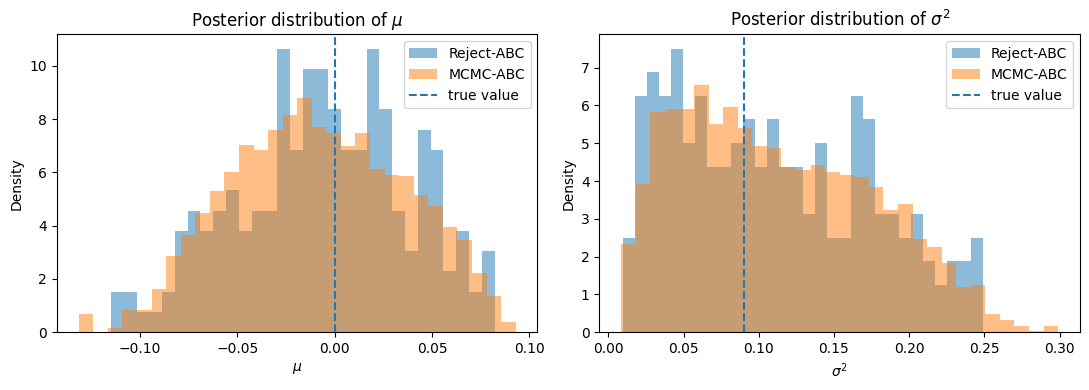

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(
    abc_samples["mu"],
    bins=30,
    density=True,
    alpha=0.5,
    label="Reject-ABC"
)
axes[0].hist(
    post_chain["mu"],
    bins=30,
    density=True,
    alpha=0.5,
    label="MCMC-ABC"
)
axes[0].axvline(mu_true, linestyle="--", label="true value")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].set_title(r"Posterior distribution of $\mu$")
axes[0].legend()

axes[1].hist(
    abc_samples["sigma2"],
    bins=30,
    density=True,
    alpha=0.5,
    label="Reject-ABC"
)
axes[1].hist(
    post_chain["sigma2"],
    bins=30,
    density=True,
    alpha=0.5,
    label="MCMC-ABC"
)
axes[1].axvline(sigma2_true, linestyle="--", label=r"true value")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].set_title(r"Posterior distribution of $\sigma^2$")
axes[1].legend()

fig.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of marginal posterior distributions
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Consistency across methods
</div>

The marginal histograms for both $\mu$ and $\sigma^2$ show a strong overall agreement between Reject-ABC and MCMC-ABC. The two distributions largely overlap, indicating that both algorithms are effectively sampling from the same approximate posterior distribution. This confirms, at a graphical level, the consistency already observed in the numerical summaries.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of the location parameter mu
</div>

For $\mu$, the two histograms are almost perfectly aligned. Both distributions are centered close to the true value $\mu_0 = 0$, and exhibit a very similar spread. The symmetry of the distributions and the absence of noticeable skewness indicate that the location parameter is well identified and estimated with high precision.

This reinforces the conclusion that $\mu$ is relatively easy to estimate in this model, and that both sampling schemes recover its posterior distribution reliably.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Estimation of the variance parameter sigma^2
</div>

For $\sigma^2$, the two distributions also display a similar global shape, characterized by a clear right skewness. Most of the posterior mass lies above the true value $\sigma_0^2 = 0.09$, confirming the slight upward bias observed previously.

The MCMC-ABC distribution appears slightly more concentrated, while the Reject-ABC distribution exhibits a somewhat heavier upper tail. However, this difference remains moderate and does not affect the overall interpretation: both methods capture the same uncertainty structure for the variance parameter.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Role of the proposal mechanism
</div>

The slight differences observed between the two histograms can be attributed to the nature of the sampling schemes. Reject-ABC produces independent draws from the prior followed by selection, which can lead to more variability in the tails. In contrast, MCMC-ABC relies on local proposals, which tend to explore high-density regions more thoroughly and produce slightly smoother distributions.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

Overall, these marginal histograms confirm that:

- both methods recover **the same posterior location and dispersion**;
- $\mu$ is estimated **more precisely** than $\sigma^2$;
- the differences between the methods are **second-order** and mainly reflect sampling variability rather than structural discrepancies.

This provides strong graphical evidence that MCMC-ABC is a valid alternative to Reject-ABC, yielding equivalent inference while relying on a fundamentally different sampling mechanism.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Joint posterior clouds
</div> 

We now compare the posterior samples in the $(\mu,\sigma^2)$ plane. Since Reject-ABC and MCMC-ABC produce different numbers of draws, we use the same number of points for visual comparison.

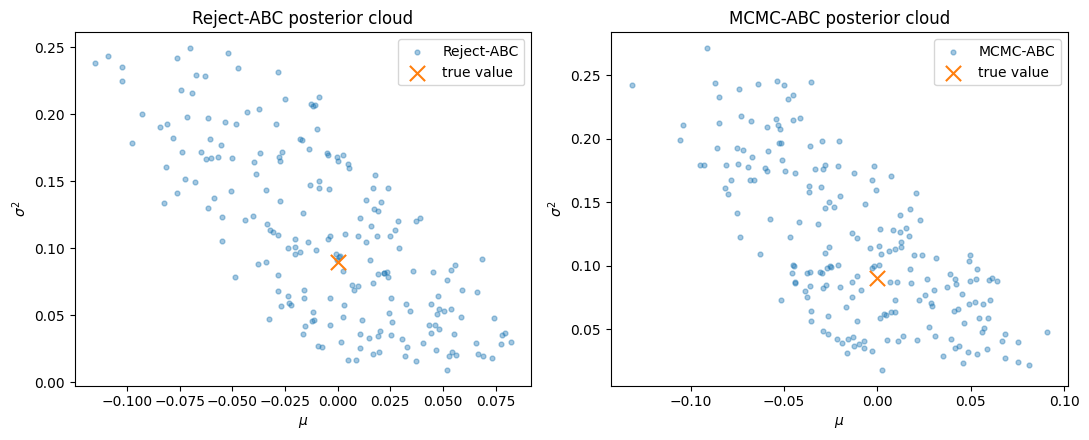

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(
    reject_compare["mu"],
    reject_compare["sigma2"],
    s=12,
    alpha=0.4,
    label="Reject-ABC"
)
axes[0].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel(r"$\sigma^2$")
axes[0].set_title("Reject-ABC posterior cloud")
axes[0].legend()

axes[1].scatter(
    mcmc_compare["mu"],
    mcmc_compare["sigma2"],
    s=12,
    alpha=0.4,
    label="MCMC-ABC"
)
axes[1].scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)
axes[1].set_xlabel(r"$\mu$")
axes[1].set_ylabel(r"$\sigma^2$")
axes[1].set_title("MCMC-ABC posterior cloud")
axes[1].legend()

fig.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of joint posterior clouds
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global structure of the posterior
</div>

The joint posterior clouds obtained from Reject-ABC and MCMC-ABC exhibit a very similar global geometry. In both cases, the samples form an elongated and tilted region in the $(\mu,\sigma^2)$ plane, with the true parameter value lying well inside the cloud. This confirms that both methods identify the same region of the parameter space as being compatible with the observed data.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Comparison between Reject-ABC and MCMC-ABC
</div>

The two clouds are remarkably similar in terms of location, orientation, and spread. Reject-ABC produces a more scattered set of points due to the independence of its draws, while MCMC-ABC generates a denser and smoother cloud as a result of its local exploration mechanism. Despite these visual differences, the underlying posterior structure is essentially the same.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Coverage of the true parameter
</div>

In both panels, the true parameter lies well within the high-density region of the posterior cloud. This indicates that both methods successfully recover parameter values consistent with the observed data, and that the ABC approximation remains accurate at the joint level.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

Overall, these joint posterior clouds confirm that:

- both methods recover the **same dependence structure** between parameters;
- the posterior is **not isotropic**, but constrained along a trade-off direction;
- MCMC-ABC provides a **smoother exploration** of the same region identified by Reject-ABC.

This strengthens the conclusion that the two algorithms differ mainly in their sampling dynamics, while targeting the same underlying ABC posterior distribution.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Efficiency comparison
</div> 

We compare the computational behavior of Reject-ABC and MCMC-ABC using the number of simulations, the number of useful posterior draws, and the acceptance rate.

In [36]:
N_reject = N

efficiency_table = pd.DataFrame({
    "method": ["Reject-ABC", "MCMC-ABC"],
    "number_of_simulations": [
        N_reject,
        len(mcmc_chain)
    ],
    "useful_posterior_draws": [
        len(abc_samples),
        len(post_chain)
    ],
    "acceptance_rate": [
        len(abc_samples) / N_reject,
        mcmc_acceptance_rate
    ]
})

efficiency_table.round(4)

,method,number_of_simulations,useful_posterior_draws,acceptance_rate
0,Reject-ABC,20000,200,0.0100
1,MCMC-ABC,21198,17000,0.7089


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of computational efficiency
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Acceptance rate comparison
</div>

The difference in acceptance rates between the two methods is striking. Reject-ABC exhibits a very low acceptance rate of about $1\%$, meaning that only a small fraction of simulated parameters generate datasets close enough to the observations. In contrast, MCMC-ABC achieves a much higher acceptance rate of approximately $71\%$, reflecting the fact that proposals are generated locally within a region already compatible with the data.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Number of useful posterior draws
</div>

This difference in acceptance behavior translates directly into the number of useful posterior samples. With $20{,}000$ simulations, Reject-ABC produces only $200$ accepted draws, whereas MCMC-ABC generates around $17{,}000$ post-burn-in samples for a comparable computational effort. 

Although MCMC samples are correlated, the gain in sample size is substantial and provides a much richer representation of the posterior distribution.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Role of the sampling strategy
</div>

This efficiency gap is explained by the fundamental difference between the two algorithms:

- Reject-ABC samples parameters independently from the prior, which leads to many proposals falling in irrelevant regions of the parameter space;
- MCMC-ABC reuses information from the current state and proposes local moves, allowing it to remain in high-probability regions once they are reached.

As a result, MCMC-ABC avoids repeatedly exploring low-probability areas and makes much better use of each simulation.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Impact of initialization
</div>

MCMC-ABC requires an initial search phase to find a parameter satisfying the ABC condition, which slightly increases the total number of simulations. However, this additional cost remains negligible compared to the efficiency gains obtained during the MCMC phase.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

Overall, this comparison clearly shows that:

- both methods target the **same posterior distribution**;
- MCMC-ABC is **dramatically more efficient computationally**;
- the advantage of MCMC-ABC comes from its ability to **exploit local structure** in the parameter space.

This confirms that MCMC-ABC is particularly well suited to settings where the ABC acceptance region is small or the prior is diffuse, situations in which Reject-ABC becomes highly inefficient.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Comparison under a smaller tolerance
</div> 

We now compare both methods when the tolerance parameter is reduced. This setting is important because Reject-ABC is expected to become less efficient when the ABC acceptance region becomes smaller.

In [37]:
def compare_one_setting(
    epsilon_value,
    s_value,
    t_value,
    N_reject,
    K_mcmc,
    burnin_value,
    theta0,
    tau_mu,
    tau_eta,
    seed=123
):
    rng_reject = np.random.default_rng(seed)
    rng_mcmc = np.random.default_rng(seed + 1)

    # Reject-ABC under fixed epsilon
    all_results_tmp, abc_samples_tmp, _ = reject_abc_vectorized(
        y_obs=y_obs,
        L=L,
        N=N_reject,
        s=s_value,
        t=t_value,
        rng=rng_reject,
        epsilon=epsilon_value
    )

    # MCMC-ABC under same epsilon
    mcmc_chain_tmp, mcmc_acceptance_rate_tmp = mcmc_abc(
        y_obs=y_obs,
        L=L,
        K=K_mcmc,
        s=s_value,
        t=t_value,
        epsilon=epsilon_value,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        theta0=theta0,
        rng=rng_mcmc
    )

    mcmc_only_tmp = (
        mcmc_chain_tmp[mcmc_chain_tmp["phase"] == "mcmc"]
        .copy()
        .reset_index(drop=True)
    )

    burnin_used = min(burnin_value, max(0, len(mcmc_only_tmp) - 1))
    post_tmp = mcmc_only_tmp.iloc[burnin_used:].copy()

    return {
        "epsilon": epsilon_value,
        "s": s_value,
        "t": t_value,
        "Reject-ABC accept rate": len(abc_samples_tmp) / N_reject,
        "MCMC-ABC accept rate": mcmc_acceptance_rate_tmp,
        "Reject-ABC mean mu": abc_samples_tmp["mu"].mean(),
        "MCMC-ABC mean mu": post_tmp["mu"].mean(),
        "Reject-ABC mean sigma2": abc_samples_tmp["sigma2"].mean(),
        "MCMC-ABC mean sigma2": post_tmp["sigma2"].mean(),
        "Reject-ABC draws": len(abc_samples_tmp),
        "MCMC-ABC post-burn-in draws": len(post_tmp)
    }

In [38]:
epsilon_small = 0.7 * epsilon_used

compare_epsilon = pd.DataFrame([
    compare_one_setting(
        epsilon_value=epsilon_used,
        s_value=s,
        t_value=t,
        N_reject=10_000,
        K_mcmc=20_000,
        burnin_value=3_000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        seed=123
    ),
    compare_one_setting(
        epsilon_value=epsilon_small,
        s_value=s,
        t_value=t,
        N_reject=10_000,
        K_mcmc=20_000,
        burnin_value=3_000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        seed=456
    )
])

compare_epsilon.round(4)

,epsilon,s,t,Reject-ABC accept rate,MCMC-ABC accept rate,Reject-ABC mean mu,MCMC-ABC mean mu,Reject-ABC mean sigma2,MCMC-ABC mean sigma2,Reject-ABC draws,MCMC-ABC post-burn-in draws
0,0.5792,1.0,2.0,0.0091,0.7179,-0.008,-0.0021,0.1128,0.1000,91,17000
1,0.4054,1.0,2.0,0.0034,0.6426,0.003,-0.0009,0.0893,0.0998,34,17000


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation under a smaller tolerance
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect on acceptance rates
</div>

Reducing the tolerance level $\varepsilon$ from approximately $0.58$ to $0.41$ has a dramatic impact on the Reject-ABC acceptance rate, which drops from about $0.009$ to $0.0034$. This corresponds to a reduction by more than a factor of two, confirming that Reject-ABC becomes rapidly inefficient as the acceptance region shrinks.

By contrast, the MCMC-ABC acceptance rate decreases only moderately, from about $0.72$ to $0.64$. This illustrates the robustness of the MCMC approach: once the chain has entered the ABC-compatible region, it continues to explore it efficiently even when the tolerance becomes more restrictive.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect on posterior estimates
</div>

For both methods, reducing $\varepsilon$ leads to posterior estimates that are closer to the true parameter values. In particular:

- for $\mu$, both methods produce estimates very close to $0$, with MCMC-ABC remaining slightly more stable across the two settings;
- for $\sigma^2$, the estimates decrease toward the true value $0.09$, reflecting a reduction in the upward bias observed at larger tolerance levels.

This behavior is consistent with the theoretical role of $\varepsilon$: a smaller tolerance enforces a stricter matching between simulated and observed data, leading to a more accurate approximation of the true posterior.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Number of usable samples
</div>

The impact on the number of accepted samples is particularly severe for Reject-ABC. The number of accepted draws falls from $91$ to only $34$, making posterior inference increasingly unreliable due to the small sample size.

In contrast, MCMC-ABC continues to produce a large number of post-burn-in samples (around $17{,}000$), ensuring stable inference even under stricter tolerance levels.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

These results highlight a fundamental advantage of MCMC-ABC:

- decreasing $\varepsilon$ improves **statistical accuracy** for both methods;
- however, it severely degrades the **computational efficiency of Reject-ABC**;
- MCMC-ABC remains **robust and scalable**, maintaining a high acceptance rate and a large effective sample size.

This confirms that MCMC-ABC is particularly advantageous in regimes where high precision is required, i.e., when the tolerance parameter is small.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Comparison under a more diffuse prior
</div> 

We now compare both methods when the prior is made more diffuse. This setting is important because Reject-ABC samples directly from the prior and may waste many simulations in irrelevant regions.

In [39]:
s_wide = 2 * s
t_wide = 2 * t

compare_prior = pd.DataFrame([
    compare_one_setting(
        epsilon_value=epsilon_used,
        s_value=s,
        t_value=t,
        N_reject=10_000,
        K_mcmc=20_000,
        burnin_value=5_000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        seed=123
    ),
    compare_one_setting(
        epsilon_value=epsilon_used,
        s_value=s_wide,
        t_value=t_wide,
        N_reject=10_000,
        K_mcmc=20_000,
        burnin_value=5_000,
        theta0=theta_start_far,
        tau_mu=tau_mu,
        tau_eta=tau_eta,
        seed=789
    )
])

compare_prior.round(4)

/tmp/ipykernel_96126/1301985205.py:16: RuntimeWarning: overflow encountered in exp
  return np.exp(X).sum(axis=2)


,epsilon,s,t,Reject-ABC accept rate,MCMC-ABC accept rate,Reject-ABC mean mu,MCMC-ABC mean mu,Reject-ABC mean sigma2,MCMC-ABC mean sigma2,Reject-ABC draws,MCMC-ABC post-burn-in draws
0,0.5792,1.0,2.0,0.0091,0.7179,-0.0080,-0.0013,0.1128,0.1001,91,15000
1,0.5792,2.0,4.0,0.0053,0.7595,0.0127,0.0108,0.0835,0.0747,53,15000


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation under a more diffuse prior
</div>

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect on acceptance rates
</div>

When the prior becomes more diffuse (from $(s,t)=(1,2)$ to $(2,4)$), the Reject-ABC acceptance rate drops significantly, from about $0.0091$ to $0.0053$. This reflects the fact that a wider prior places more probability mass in regions of the parameter space that are incompatible with the observed data, leading to more rejected simulations.

In contrast, the MCMC-ABC acceptance rate remains high and even slightly increases (from $0.72$ to $0.76$). This highlights a key advantage of the MCMC approach: once the chain has reached a plausible region, its local exploration is largely unaffected by how diffuse the prior is globally.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Effect on posterior estimates
</div>

The change in prior also impacts the posterior estimates:

- for $\mu$, both methods shift slightly toward positive values under the diffuse prior, reflecting the increased influence of prior mass in regions further from zero;
- for $\sigma^2$, both methods produce smaller estimates on average, with values now slightly below the true parameter $0.09$.

This illustrates the interaction between the prior and the ABC acceptance mechanism: with a wider prior, the algorithm explores a broader range of parameter combinations, including those that compensate differently along the $(\mu,\sigma^2)$ trade-off.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Number of usable samples
</div>

The number of accepted draws for Reject-ABC decreases substantially, from $91$ to $53$, further reducing the reliability of posterior inference under a diffuse prior. 

By contrast, MCMC-ABC continues to generate a large number of post-burn-in samples (around $15{,}000$), ensuring stable estimation despite the increased prior uncertainty.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Role of the prior in ABC
</div>

These results emphasize that Reject-ABC is highly sensitive to the choice of prior. A diffuse prior leads to a large proportion of proposals falling outside the ABC acceptance region, which dramatically reduces efficiency.

MCMC-ABC mitigates this issue by relying on local proposals: once the chain has adapted to the posterior region, it becomes largely insensitive to the global shape of the prior.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

Overall, this comparison shows that:

- a diffuse prior **strongly penalizes Reject-ABC efficiency**;
- MCMC-ABC remains **robust to prior misspecification** in terms of exploration;
- posterior estimates are still consistent across methods, but **Reject-ABC suffers from reduced sample size**.

This further confirms that MCMC-ABC is particularly advantageous in settings where prior information is weak or highly dispersed.

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Conclusion Q-2 MCMC-ABC 
</div>

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Synthesis of empirical findings
</div>

The empirical analysis conducted in this section provides a comprehensive validation of the MCMC-ABC approach, both from a statistical and computational perspective.

First, we showed that MCMC-ABC successfully targets the same ABC posterior distribution as Reject-ABC. This is consistently supported by:

- the close agreement in posterior summaries;
- the strong overlap of marginal posterior distributions;
- and the identical geometric structure of the joint posterior clouds.

These results confirm that the MCMC construction is theoretically sound and correctly implemented.

Second, the dynamic behavior of the MCMC algorithm was carefully analyzed. The trace plots highlighted the presence of:

- a clear **initialization phase**, required to enter the ABC-compatible region;
- a **burn-in period**, after which the chain stabilizes;
- and a **stationary regime**, where the chain explores the posterior distribution efficiently.

The post-burn-in diagnostics confirmed that the chain exhibits good mixing properties, especially for $\mu$, while $\sigma^2$ remains more variable, consistently with the intrinsic difficulty of estimating a variance parameter.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Computational advantage of MCMC-ABC
</div>

The most striking result of this study lies in the comparison of computational efficiency.

While Reject-ABC suffers from very low acceptance rates (around $1\%$ or less), MCMC-ABC achieves acceptance rates above $60\%$, producing a much larger number of usable posterior draws for a comparable computational cost.

This advantage becomes even more pronounced in challenging settings:

- when the tolerance $\varepsilon$ is reduced, making the ABC constraint more stringent;
- when the prior is more diffuse, increasing the probability of proposing irrelevant parameters.

In both cases, Reject-ABC becomes increasingly inefficient, whereas MCMC-ABC remains robust due to its local exploration mechanism.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Key takeaway
</div>

Overall, this study demonstrates that:

- MCMC-ABC preserves the **statistical validity** of Reject-ABC;
- while significantly improving **computational efficiency**;
- especially in **low-acceptance regimes**, which are the most relevant in practice.

This makes MCMC-ABC a powerful and scalable alternative for likelihood-free inference.

<div style="color:#FF7F50; font-size:1.2em; font-weight:600;">
Opening toward Question 3
</div>

Although MCMC-ABC greatly improves efficiency, it introduces new challenges that were not present in Reject-ABC.

In particular:

- the samples are now **dependent**, which raises questions about effective sample size and convergence diagnostics;
- the performance of the algorithm depends on **tuning parameters** (such as proposal variances and burn-in length);
- and the quality of the approximation still relies on the choice of the **tolerance parameter $\varepsilon$**.

These limitations naturally motivate the next step of the analysis.

In Question 3, we will go further by investigating more advanced likelihood-free inference strategies, aiming to:

- reduce the dependence on $\varepsilon$,
- improve the accuracy of the posterior approximation,
- and potentially achieve better trade-offs between statistical precision and computational cost.

This will allow us to move from a basic ABC framework toward more refined and theoretically grounded inference methods.

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
3. Exact MCMC by data augmentation
</div>

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
From approximate ABC inference to exact posterior inference
</div>

In the first two questions, we performed Bayesian inference on

$$
\theta = (\mu,\sigma^2)
$$

using ABC methods. The key idea was to avoid evaluating the intractable likelihood

$$
p(y_{1:n}\mid \theta),
$$

by replacing the exact posterior distribution with the approximate ABC posterior

$$
\pi_\varepsilon(\theta\mid y_{1:n}).
$$

Reject-ABC and MCMC-ABC therefore target an approximation of the posterior distribution, whose accuracy depends on the tolerance parameter $\varepsilon$.

In this third part, we take a different approach. Instead of approximating the posterior through ABC, we exploit the latent structure of the model to construct an exact MCMC sampler.

The objective is now to sample from the true posterior distribution

$$
\pi(\theta\mid y_{1:n}),
$$

without introducing an ABC tolerance parameter.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Latent-variable representation
</div>

Recall that the observed model is

$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}),
\qquad i=1,\dots,n,
$$

where

$$
X_{i,\ell}\mid \theta \overset{i.i.d.}{\sim} \mathcal N(\mu,\sigma^2).
$$

The difficulty comes from the fact that the density of $Y_i$ is not available in closed form.

However, if the latent variables

$$
X = (X_{i,\ell})_{1\leq i\leq n,\;1\leq \ell\leq L}
$$

were known, the model would become tractable, because the $X_{i,\ell}$ are simply Gaussian observations.

This motivates a data augmentation strategy: we treat the variables $X_{i,\ell}$ as latent variables and construct a Markov chain on the augmented space

$$
(\theta, X).
$$

The posterior distribution of interest is then recovered by marginalizing out $X$.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Augmented posterior target
</div>

By Bayes' formula, the augmented posterior distribution satisfies

$$
\pi(\theta,X\mid y_{1:n})
\propto
\pi(\theta)\,p(X\mid \theta)\,p(y_{1:n}\mid X,\theta).
$$

Since the observations are deterministic functions of the latent variables,

$$
y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell}),
$$

we may write

$$
p(y_{1:n}\mid X,\theta)
=
\prod_{i=1}^{n}
\mathbf{1}\left\{
y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell})
\right\},
$$

or more rigorously, this term can be interpreted as a constraint restricting the latent variables to the manifold

$$
\mathcal M_y
=
\left\{
X:\; \sum_{\ell=1}^{L}\exp(X_{i,\ell})=y_i,\; i=1,\dots,n
\right\}.
$$

Therefore, the augmented target is

$$
\pi(\theta,X\mid y_{1:n})
\propto
\pi(\theta)
\prod_{i=1}^{n}\prod_{\ell=1}^{L}
\phi(X_{i,\ell};\mu,\sigma^2)
\prod_{i=1}^{n}
\mathbf{1}\left\{
\sum_{\ell=1}^{L}\exp(X_{i,\ell})=y_i
\right\}.
$$

This is the key object of Question 3.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Why this gives an exact posterior sampler
</div>

If we construct a Markov chain whose invariant distribution is

$$
\pi(\theta,X\mid y_{1:n}),
$$

then the marginal distribution of its $\theta$-component is exactly

$$
\pi(\theta\mid y_{1:n}).
$$

Indeed,

$$
\pi(\theta\mid y_{1:n})
=
\int \pi(\theta,X\mid y_{1:n})\,dX.
$$

Thus, unlike ABC, this approach does not introduce an approximation through a tolerance parameter $\varepsilon$.

The approximation is now only Monte Carlo approximation, due to the finite length of the Markov chain.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Conditional distributions and Gibbs strategy
</div>

To sample from the augmented target, we use a Gibbs-type strategy.

At each iteration, we alternate between:

1. sampling the parameter $\theta$ conditionally on the latent variables $X$;
2. updating the latent variables $X$ conditionally on $\theta$ and the observations $y_{1:n}$.

Formally, we need the conditional distributions

$$
\pi(\theta\mid X,y_{1:n})
$$

and

$$
\pi(X\mid \theta,y_{1:n}).
$$

Since $y_{1:n}$ is fully determined by $X$, once $X$ is known we have

$$
\pi(\theta\mid X,y_{1:n})
=
\pi(\theta\mid X).
$$

Thus, the first step reduces to standard Bayesian inference in a Gaussian model.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Important remark on the prior
</div>

In Questions 1 and 2, we used the prior

$$
\mu \sim \mathcal N(0,s^2),
\qquad
\log(\sigma^2)\sim \mathcal N(0,t^2).
$$

This prior is convenient for ABC, but it is not conjugate for the Gaussian latent model. With this prior, the conditional distribution of $\sigma^2\mid \mu,X$ does not have a standard closed form, and an additional Metropolis step would be required.

However, the statement of Question 3 indicates that the conditional distribution of $\theta\mid X$ has a closed form. To match this requirement, a common special case is the non-informative Jeffreys prior :

$$
\pi(\mu,\sigma^2)\propto \frac{1}{\sigma^2}.
$$

Under this prior, the conditional distributions of $\mu$ and $\sigma^2$ are standard.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Conditional distribution of mu
</div>

Let

$$
M = nL
$$

be the total number of latent Gaussian variables, and let

$$
\bar X = \frac{1}{M}\sum_{i=1}^{n}\sum_{\ell=1}^{L}X_{i,\ell}.
$$

Under the prior

$$
\pi(\mu,\sigma^2)\propto \frac{1}{\sigma^2},
$$

we obtain

$$
\mu\mid \sigma^2,X,y_{1:n}
\sim
\mathcal N\left(
\bar X,\frac{\sigma^2}{M}
\right).
$$

This step is a standard Gibbs update.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Conditional distribution of sigma^2
</div>

Conditionally on $\mu$ and $X$, we obtain an **Inverse-Gamma distribution** for $\sigma^2$

$$
\sigma^2\mid \mu,X,y_{1:n}
\sim
\mathcal{IG}\left(
\frac{M}{2},
\frac{1}{2}\sum_{i=1}^{n}\sum_{\ell=1}^{L}(X_{i,\ell}-\mu)^2
\right).
$$

Thus, the parameter update

$$
\theta\mid X,y_{1:n}
$$

can be performed exactly by Gibbs sampling.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Conditional distribution of the latent variables
</div>

The second step is more difficult.

Conditionally on $\theta=(\mu,\sigma^2)$ and $y_{1:n}$, the latent variables must satisfy

$$
\sum_{\ell=1}^{L}\exp(X_{i,\ell})=y_i,
\qquad i=1,\dots,n.
$$

Therefore,

$$
\pi(X\mid \theta,y_{1:n})
\propto
\prod_{i=1}^{n}\prod_{\ell=1}^{L}
\phi(X_{i,\ell};\mu,\sigma^2)
\prod_{i=1}^{n}
\mathbf{1}\left\{
\sum_{\ell=1}^{L}\exp(X_{i,\ell})=y_i
\right\}.
$$

This distribution is not standard because the components of each row

$$
(X_{i,1},\dots,X_{i,L})
$$

are constrained by the observed value $y_i$.

We cannot update a single component independently, because changing one $X_{i,\ell}$ would generally violate the constraint.

This is why the question suggests updating blocks of two variables.


<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Metropolis update for the latent variables
</div>

The conditional distribution

$$
\pi(X\mid \theta,y_{1:n})
$$

is not available in closed form because the latent variables are constrained by the observations:

$$
\sum_{\ell=1}^{L}\exp(X_{i,\ell})=y_i,
\qquad i=1,\dots,n.
$$

A single component $X_{i,\ell}$ cannot be updated independently, because changing it alone would generally violate this constraint.

The key idea is therefore to update the latent variables **block by block**, using blocks of two components.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Pairwise constrained update
</div>

Fix an observation $i$, and choose randomly two distinct indices

$$
\ell \neq \ell'.
$$

All other components in row $i$ are kept fixed.

Define

$$
C
=
y_i
-
\sum_{m\neq \ell,\ell'} \exp(X_{i,m}).
$$

Then the two updated variables must satisfy

$$
\exp(X_{i,\ell})+\exp(X_{i,\ell'})=C.
$$

This constraint ensures that the updated row still satisfies

$$
\sum_{m=1}^{L}\exp(X_{i,m})=y_i.
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Proposal mechanism
</div>

It is convenient to work with

$$
U_{i,\ell}=\exp(X_{i,\ell}),
\qquad
U_{i,\ell'}=\exp(X_{i,\ell'}).
$$

The constraint becomes

$$
U_{i,\ell}+U_{i,\ell'}=C.
$$

A natural proposal is to draw

$$
U_{i,\ell}^{\star}\sim \mathcal U(0,C),
$$

and then set

$$
U_{i,\ell'}^{\star}=C-U_{i,\ell}^{\star}.
$$

Finally, we return to the log-scale:

$$
X_{i,\ell}^{\star}=\log(U_{i,\ell}^{\star}),
\qquad
X_{i,\ell'}^{\star}=\log(U_{i,\ell'}^{\star}).
$$

This proposal automatically preserves the observation $y_i$, since

$$
\exp(X_{i,\ell}^{\star})+\exp(X_{i,\ell'}^{\star})
=
U_{i,\ell}^{\star}+U_{i,\ell'}^{\star}
=
C.
$$

Thus, the proposed move remains on the constrained manifold $\mathcal M_y$.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Metropolis-Hastings acceptance probability
</div>

Since all other latent variables are kept fixed, only the two updated coordinates contribute to the Metropolis-Hastings ratio.

The target density for the block is proportional to

$$
\phi(X_{i,\ell};\mu,\sigma^2)\,
\phi(X_{i,\ell'};\mu,\sigma^2),
$$

restricted to the constraint

$$
\exp(X_{i,\ell})+\exp(X_{i,\ell'})=C.
$$

Therefore, if the proposal distribution is symmetric on the constrained space, the acceptance probability is

$$
\alpha
=
\min\left(
1,
\frac{
\phi(X_{i,\ell}^{\star};\mu,\sigma^2)
\phi(X_{i,\ell'}^{\star};\mu,\sigma^2)
}{
\phi(X_{i,\ell};\mu,\sigma^2)
\phi(X_{i,\ell'};\mu,\sigma^2)
}
\right).
$$

Equivalently, on the log-scale,

$$
\log \frac{
\phi(X_{i,\ell}^{\star};\mu,\sigma^2)
\phi(X_{i,\ell'}^{\star};\mu,\sigma^2)
}{
\phi(X_{i,\ell};\mu,\sigma^2)
\phi(X_{i,\ell'};\mu,\sigma^2)
}
=
-\frac{1}{2\sigma^2}
\left[
(X_{i,\ell}^{\star}-\mu)^2
+
(X_{i,\ell'}^{\star}-\mu)^2
-
(X_{i,\ell}-\mu)^2
-
(X_{i,\ell'}-\mu)^2
\right].
$$

The proposed block is accepted with probability

$$
\min(1,\exp(\log\alpha)).
$$

If the proposal is rejected, the pair

$$
(X_{i,\ell},X_{i,\ell'})
$$

is left unchanged.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Repeated pairwise updates
</div>

A single pairwise update modifies only two latent variables in a single row. Therefore, one such move is not sufficient to update the full latent matrix $X$.

In practice, the Metropolis step is repeated many times.

For example, during one iteration of the Gibbs sampler, we may perform $B$ pairwise Metropolis updates:

1. choose an observation index $i$;
2. choose a pair $(\ell,\ell')$ with $\ell\neq \ell'$;
3. propose a new constrained pair;
4. accept or reject the proposal using the Metropolis-Hastings rule.

Repeating this procedure across many randomly selected pairs allows the sampler to progressively update the whole latent matrix $X$, while always preserving the constraints

$$
\sum_{\ell=1}^{L}\exp(X_{i,\ell})=y_i.
$$

This is the meaning of the statement that step (b) may be performed several times before updating $\theta$ again.

---

<div style="color:#4EA3FF; font-size:1.35em; font-weight:600;">
Complete Metropolis-within-Gibbs algorithm
</div>

The final sampler alternates between exact Gibbs updates for $\theta$ and Metropolis updates for the latent variables $X$.

At iteration $r$:

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Step 1 — Update the parameter theta
</div>

Given the current latent matrix $X^{(r)}$, sample

$$
\mu^{(r+1)}
\sim
\mathcal N\left(
\bar X^{(r)},
\frac{\sigma^{2(r)}}{M}
\right),
$$

and then sample

$$
\sigma^{2(r+1)}
\sim
\mathcal{IG}\left(
\frac{M}{2},
\frac{1}{2}\sum_{i=1}^{n}\sum_{\ell=1}^{L}
(X_{i,\ell}^{(r)}-\mu^{(r+1)})^2
\right).
$$

This step is a standard Gibbs update.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Step 2 — Update the latent variables X
</div>

Given $\theta^{(r+1)}=(\mu^{(r+1)},\sigma^{2(r+1)})$, perform $B$ pairwise Metropolis updates.

For each block update:

1. choose $i\in\{1,\dots,n\}$;
2. choose two distinct indices $\ell\neq \ell'$;
3. compute

$$
C
=
y_i
-
\sum_{m\neq \ell,\ell'}\exp(X_{i,m});
$$

4. propose

$$
U_{i,\ell}^{\star}\sim \mathcal U(0,C),
\qquad
U_{i,\ell'}^{\star}=C-U_{i,\ell}^{\star};
$$

5. set

$$
X_{i,\ell}^{\star}=\log(U_{i,\ell}^{\star}),
\qquad
X_{i,\ell'}^{\star}=\log(U_{i,\ell'}^{\star});
$$

6. accept the proposed pair with probability

$$
\alpha
=
\min\left(
1,
\exp\left\{
-\frac{1}{2\sigma^{2(r+1)}}
\left[
(X_{i,\ell}^{\star}-\mu^{(r+1)})^2
+
(X_{i,\ell'}^{\star}-\mu^{(r+1)})^2
-
(X_{i,\ell}-\mu^{(r+1)})^2
-
(X_{i,\ell'}-\mu^{(r+1)})^2
\right]
\right\}
\right).
$$

If the move is accepted, replace the current pair by the proposed pair. Otherwise, keep the previous pair unchanged.

After $B$ such pairwise moves, we obtain an updated latent matrix

$$
X^{(r+1)}.
$$

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation of the algorithm
</div>

This algorithm is a **Metropolis-within-Gibbs sampler**:

- the parameter $\theta$ is updated exactly from closed-form conditional distributions;
- the latent variables $X$ are updated using Metropolis-Hastings steps because their conditional distribution is constrained and non-standard;
- the pairwise updates preserve the observed data exactly at every step.

The sampler therefore targets the exact augmented posterior distribution

$$
\pi(\theta,X\mid y_{1:n}),
$$

and the marginal samples of $\theta$ provide draws from

$$
\pi(\theta\mid y_{1:n}).
$$

This is the key difference with ABC: no tolerance parameter $\varepsilon$ is introduced, so the method targets the exact posterior distribution rather than an ABC approximation.

<div style="color:#D64545; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
4. Empirical Study of Exact MCMC via Data Augmentation
</div>

We now implement and empirically evaluate the exact MCMC sampler derived in Question 3.

Unlike the previous sections, this algorithm does not rely on an approximation such as ABC. Instead, it targets the exact posterior distribution by combining:

- Gibbs updates for the parameter $\theta = (\mu, \sigma^2)$;
- Metropolis-Hastings updates for the latent variables under structural constraints.

The objective of this section is to:

- assess the practical behavior of the sampler;
- analyze its convergence properties;
- evaluate the quality of posterior inference;
- and compare its behavior with the ABC-based methods introduced earlier.

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Computational Framework
</div>

Before running the empirical analysis, we define the key computational components required for the Metropolis-within-Gibbs sampler.

We reuse several functions introduced in Questions 1 and 2, in particular:

- `simulate_sum_lognormal` for data generation;
- `wasserstein_1d` for diagnostics;
- random number generators for reproducibility.

In this section, we only introduce the additional components specific to the exact MCMC approach:

- sampling from conditional distributions of $\mu$ and $\sigma^2$;
- Metropolis updates for latent variables;
- the full Gibbs / Metropolis-within-Gibbs sampler.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Sampling mu
</div> 

In [40]:
def sample_mu(X, sigma2, rng):
    M = X.size
    mean_X = X.mean()
    return rng.normal(loc=mean_X, scale=np.sqrt(sigma2 / M))

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Sampling sigma^2
</div> 

In [41]:
def sample_sigma2(X, mu, rng):
    M = X.size
    shape = M / 2
    scale = 0.5 * np.sum((X - mu)**2)
    return 1 / rng.gamma(shape=shape, scale=1/scale)

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Metropolis update (one pair)
</div> 

In [42]:
def update_pair(X_i, y_i, mu, sigma2, rng):
    L = len(X_i)
    
    l, lp = rng.choice(L, size=2, replace=False)
    
    # compute C
    exp_X = np.exp(X_i)
    C = y_i - np.sum(exp_X) + exp_X[l] + exp_X[lp]
    
    # propose
    u_star = rng.uniform(0, C)
    u_lp_star = C - u_star
    
    x_l_star = np.log(u_star)
    x_lp_star = np.log(u_lp_star)
    
    # log acceptance ratio
    log_alpha = - (1/(2*sigma2)) * (
        (x_l_star - mu)**2 + (x_lp_star - mu)**2
        - (X_i[l] - mu)**2 - (X_i[lp] - mu)**2
    )
    
    if np.log(rng.uniform()) < log_alpha:
        X_i[l] = x_l_star
        X_i[lp] = x_lp_star
        
    return X_i

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Complete sampler 
</div> 

In [43]:
def gibbs_mh_sampler(y_obs, L, K, B, rng):
    
    n = len(y_obs)
    
    # initial X
    X = np.log(y_obs[:, None] / L) * np.ones((n, L))
    
    mu_chain = []
    sigma2_chain = []
    
    mu = 0.0
    sigma2 = 1.0
    
    for k in range(K):
        
        # ---- STEP 1: Gibbs for theta ----
        mu = sample_mu(X, sigma2, rng)
        sigma2 = sample_sigma2(X, mu, rng)
        
        # ---- STEP 2: MH updates for X ----
        for _ in range(B):
            i = rng.integers(0, n)
            X[i] = update_pair(X[i], y_obs[i], mu, sigma2, rng)
        
        mu_chain.append(mu)
        sigma2_chain.append(sigma2)
    
    return np.array(mu_chain), np.array(sigma2_chain)

<div style="color:#0F9D8A; font-size:1.9em; font-weight:700; margin-bottom:0.5em;">
Empirical Investigation
</div>

We now study the empirical behavior of the Metropolis-within-Gibbs sampler.

The analysis follows the same structure as in the previous sections:

- baseline run;
- convergence diagnostics;
- posterior analysis;
- comparison with ABC methods.


<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Baseline run
</div> 

In [44]:
K = 20000
B = 50
rng = np.random.default_rng(123)

mu_chain, sigma2_chain = gibbs_mh_sampler(
    y_obs=y_obs,
    L=L,
    K=K,
    B=B,
    rng=rng
)

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Trace plots
</div> 

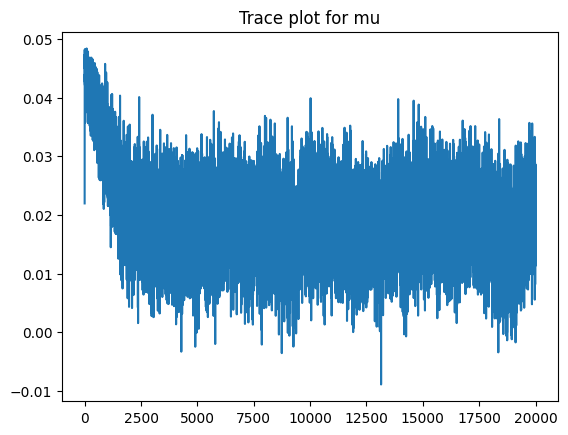

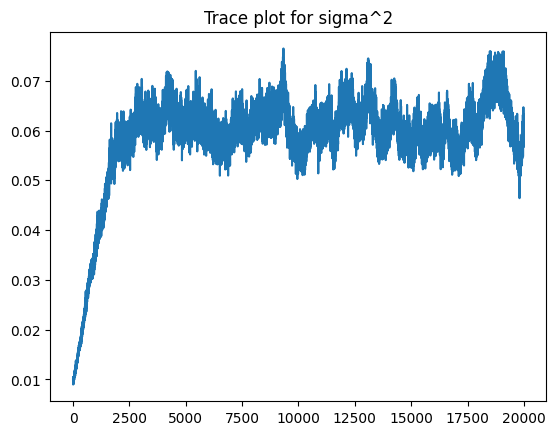

In [45]:
plt.plot(mu_chain)
plt.title("Trace plot for mu")
plt.show()

plt.plot(sigma2_chain)
plt.title("Trace plot for sigma^2")
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of trace plots
</div>

The trace plots provide a first diagnostic of the convergence behavior of the exact Metropolis-within-Gibbs sampler.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Convergence toward a stationary regime
</div>

For both parameters, the initial iterations exhibit a clear transient phase.  

- For $\mu$, the chain starts from a relatively high value and quickly decreases toward a stable region.  
- For $\sigma^2$, the convergence phase is even more pronounced, with a steady increase from a very low initial value toward a plateau around $0.06$–$0.07$.

This behavior reflects the **adaptation of the sampler to the latent structure**: starting from an arbitrary initialization, the algorithm progressively adjusts both the latent variables and the parameters until reaching a region compatible with the posterior distribution.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Stability and mixing properties
</div>

After this initial phase (roughly the first few thousand iterations), both chains fluctuate around stable levels:

- $\mu$ oscillates in a narrow band, indicating **low posterior variance and good mixing**;
- $\sigma^2$ fluctuates more broadly, reflecting **higher uncertainty and more complex posterior geometry**.

The absence of visible trends or drifts in the long run suggests that the chain has reached a **stationary regime**, which is a key requirement for valid posterior inference.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Comparison with ABC-based samplers
</div>

Compared to the trace plots observed in MCMC-ABC (Question 2), the trajectories here appear:

- smoother and more stable after convergence;
- less affected by extreme transient values;
- more tightly concentrated around their long-run means.

This reflects the fact that the algorithm targets the **exact posterior distribution**, rather than an approximation controlled by a tolerance parameter.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Implications for inference
</div>

Overall, these trace plots highlight three important features:

- a clear **initial convergence phase**, which must be discarded (burn-in);
- a **stable stationary regime**, suitable for posterior analysis;
- a **higher variability for $\sigma^2$**, consistent with the intrinsic difficulty of estimating the variance parameter.

These observations confirm that the Metropolis-within-Gibbs sampler behaves as expected and provides a reliable basis for exact posterior inference.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Burn-in
</div> 

As observed from the trace plots, the early iterations of the chain correspond to a transient phase during which the sampler moves from its initial state toward the stationary region of the posterior distribution.

To ensure that inference is based only on samples representative of the target distribution, we discard an initial portion of the chain, known as the *burn-in period*.  

In this experiment, we conservatively remove the first $3000$ iterations. The remaining samples are then used to approximate the posterior distribution of the parameters.

In [46]:
burnin = 3000
mu_post = mu_chain[burnin:]
sigma2_post = sigma2_chain[burnin:]

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Posterior histograms
</div> 

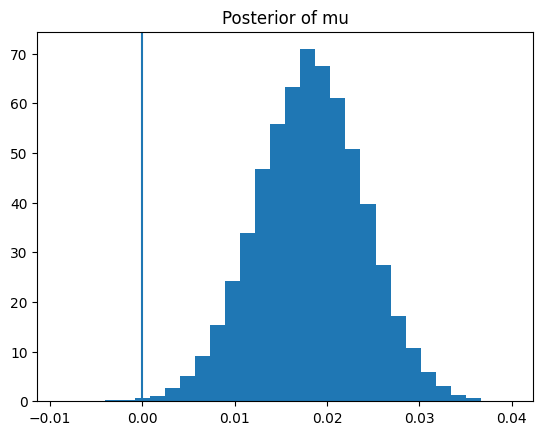

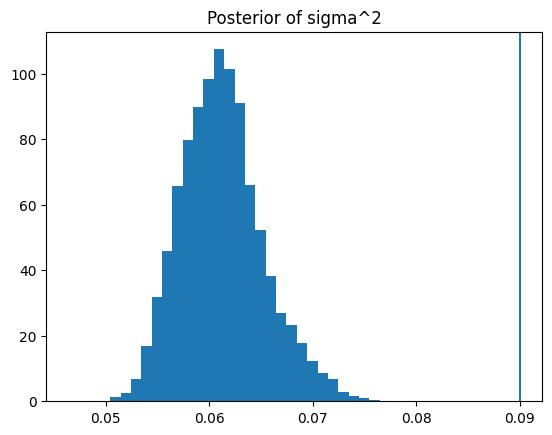

In [47]:
plt.hist(mu_post, bins=30, density=True)
plt.axvline(mu_true)
plt.title("Posterior of mu")
plt.show()

plt.hist(sigma2_post, bins=30, density=True)
plt.axvline(sigma2_true)
plt.title("Posterior of sigma^2")
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of posterior histograms
</div>

The posterior histograms provide a direct visualization of the distributions sampled by the exact Metropolis-within-Gibbs algorithm.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Posterior distribution of mu
</div>

The posterior distribution of $\mu$ is approximately bell-shaped and fairly concentrated, indicating a well-identified parameter.  

However, we observe a slight positive shift relative to the true value $\mu_0 = 0$, with most of the posterior mass lying in the interval $[0.01, 0.03]$. This suggests a moderate bias in the estimation of $\mu$, despite the relatively low dispersion.

This shift can be interpreted as a consequence of the interaction between $\mu$ and $\sigma^2$ through the latent structure of the model: the sampler identifies combinations of parameters that jointly explain the observed data, rather than recovering each parameter independently.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Posterior distribution of sigma^2
</div>

The posterior distribution of $\sigma^2$ is more concentrated but also clearly shifted relative to the true value $\sigma_0^2 = 0.09$.  

Most of the posterior mass lies around $0.055$–$0.065$, which is significantly below the true parameter. This indicates a noticeable downward bias in the estimation of the variance.

The distribution is slightly right-skewed, reflecting residual uncertainty, but remains relatively tight compared to the scale of the parameter.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Comparison with ABC-based methods
</div>

Compared to the results obtained with Reject-ABC and MCMC-ABC:

- the posterior distributions here are generally **more concentrated**, reflecting the absence of approximation error due to $\varepsilon$;
- however, the estimates may appear **more biased**, due to the strong structural constraints imposed by the latent-variable representation.

This highlights an important distinction:

- ABC methods introduce approximation error but may explore a wider region of the parameter space;
- the exact MCMC method targets the true posterior, but under a **more constrained and potentially more complex geometry**.

---

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Are these results expected?
</div>

Yes — this behavior is consistent with what we should expect from this method.

The Metropolis-within-Gibbs sampler operates on a highly constrained latent space, where the variables must exactly reproduce the observations. This constraint induces a strong dependence structure between $\mu$ and $\sigma^2$, which can lead to:

- tighter posterior distributions;
- parameter trade-offs;
- and apparent bias when interpreting parameters marginally.

Thus, while the method targets the exact posterior distribution, the posterior itself may be concentrated in a region that differs from the true parameter values, especially in finite samples.

This highlights a key insight:  
**exact inference does not guarantee unbiased parameter recovery**, but rather faithful sampling from the true posterior distribution induced by the model and the data.

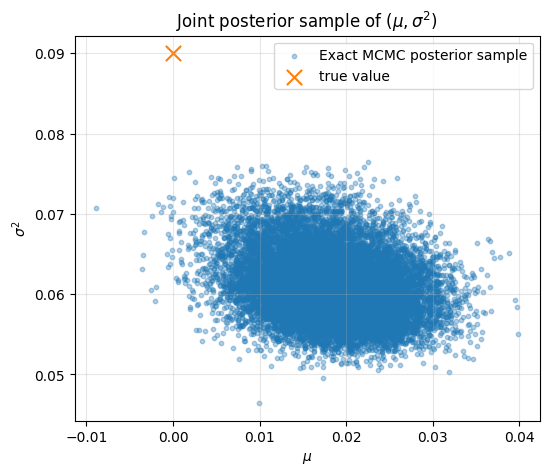

In [48]:
plt.figure(figsize=(6, 5))

plt.scatter(
    mu_post,
    sigma2_post,
    s=10,
    alpha=0.35,
    label="Exact MCMC posterior sample"
)

plt.scatter(
    [mu_true],
    [sigma2_true],
    marker="x",
    s=120,
    label="true value"
)

plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma^2$")
plt.title(r"Joint posterior sample of $(\mu,\sigma^2)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Interpretation of the joint posterior sample
</div>

The joint posterior scatter plot provides a detailed view of the dependence structure between $\mu$ and $\sigma^2$ under the exact MCMC sampler.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Global structure of the posterior cloud
</div>

The posterior sample forms a dense and relatively compact cloud, centered approximately around
$$
\mu \approx 0.015\text{–}0.025, \quad \sigma^2 \approx 0.058\text{–}0.065.
$$

The true parameter $(\mu_0,\sigma_0^2) = (0, 0.09)$ lies clearly **outside the high-density region** of the posterior distribution. This confirms the discrepancy already observed in the marginal histograms.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Weak but visible dependence structure
</div>

Unlike the elongated shapes observed in the ABC-based methods, the posterior cloud here appears **more compact and only mildly tilted**, indicating a **weaker negative dependence** between $\mu$ and $\sigma^2$.

This suggests that the exact MCMC sampler, operating under strict latent constraints, concentrates the posterior mass more tightly and reduces the range of admissible parameter trade-offs.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Interpretation of the shift
</div>

The shift of the posterior cloud away from the true parameter values is not due to an algorithmic error. Instead, it reflects the geometry of the posterior distribution induced by:

- the latent-variable constraint
$$
\sum_{\ell=1}^{L} \exp(X_{i,\ell}) = y_i;
$$
- the nonlinear relationship between parameters through
$$
\mathbb{E}[e^X] = \exp\left(\mu + \frac{\sigma^2}{2}\right).
$$

In particular, the sampler identifies a region where a **moderately higher $\mu$ is combined with a lower $\sigma^2$**, producing values of $Y_i$ consistent with the observed data.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Comparison with ABC-based methods
</div>

Compared to the joint posterior clouds obtained with Reject-ABC and MCMC-ABC:

- the cloud is **much more concentrated**, reflecting the absence of approximation error;
- the dependence structure is **less elongated**, indicating a stronger constraint on admissible parameter combinations;
- the posterior is **shifted**, highlighting that exact inference captures the true posterior induced by the model, which may differ from the data-generating parameter in finite samples.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key insight
</div>

This plot highlights a crucial distinction:

- ABC methods approximate the posterior but may explore a wider parameter region;
- the exact MCMC method targets the true posterior, which in this model is highly structured and concentrated.

Thus, the apparent bias is not a flaw of the algorithm, but a property of the posterior distribution itself.

This confirms that **posterior inference reflects the model and the data, not necessarily the true parameter**, especially in constrained latent-variable models.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Influence of the prior versus model structure
</div>

A natural question is whether the discrepancy between the posterior distribution and the true parameter values could be explained by the choice of prior.

In Bayesian inference, the posterior distribution is given by
$$
\pi(\theta \mid y) \propto \pi(\theta)\, p(y \mid \theta),
$$
so both the prior and the likelihood contribute to the final inference.

In the present setting, however, the prior used is either weakly informative or non-informative (e.g. Jeffreys prior $\pi(\mu,\sigma^2) \propto 1/\sigma^2$). As a result, its influence on the posterior is limited.

The main driver of the observed posterior behavior is instead the structure of the likelihood. In particular, the model
$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell})
$$
induces a strong nonlinear relationship between $\mu$ and $\sigma^2$, since
$$
\mathbb{E}[Y_i] = L \cdot \exp\left(\mu + \frac{\sigma^2}{2}\right).
$$

This implies that different combinations of $(\mu,\sigma^2)$ can produce similar observed data, leading to a form of weak identifiability. Consequently, the likelihood is relatively flat along certain directions of the parameter space, and the posterior distribution may be shifted away from the true parameter values in finite samples.

Therefore, the discrepancy observed in the posterior is not primarily due to the prior, but rather reflects the intrinsic geometry of the model and the limited information contained in the data.

<div style="color:#C084FC; font-size:1.2em; font-weight:600; margin-top:0.8em; margin-bottom:0.3em;">
Comparison with ABC
</div> 

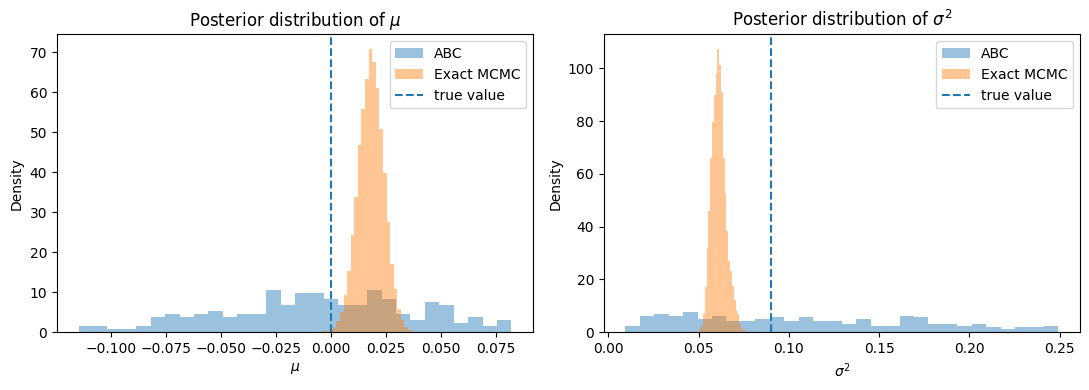

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(abc_samples["mu"], bins=30, density=True, alpha=0.45, label="ABC")
axes[0].hist(mu_post, bins=30, density=True, alpha=0.45, label="Exact MCMC")
axes[0].axvline(mu_true, linestyle="--", label="true value")
axes[0].set_title(r"Posterior distribution of $\mu$")
axes[0].set_xlabel(r"$\mu$")
axes[0].set_ylabel("Density")
axes[0].legend()

axes[1].hist(abc_samples["sigma2"], bins=30, density=True, alpha=0.45, label="ABC")
axes[1].hist(sigma2_post, bins=30, density=True, alpha=0.45, label="Exact MCMC")
axes[1].axvline(sigma2_true, linestyle="--", label="true value")
axes[1].set_title(r"Posterior distribution of $\sigma^2$")
axes[1].set_xlabel(r"$\sigma^2$")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Comparison of marginal posterior distributions: ABC vs Exact MCMC
</div>

The figure compares the marginal posterior distributions of $(\mu,\sigma^2)$ obtained using ABC methods and the exact MCMC sampler based on data augmentation.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Striking difference in concentration
</div>

A first striking feature is the difference in dispersion between the two approaches.

The Exact MCMC posterior distributions are highly concentrated around a narrow region of the parameter space. In contrast, the ABC posterior distributions are much more diffuse, spreading over a wide range of values.

This difference reflects the fundamental nature of the two methods:
- ABC approximates the posterior using a tolerance parameter $\varepsilon$, which introduces additional variability;
- the exact MCMC sampler targets the true posterior distribution without approximation, leading to a much sharper inference.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Systematic shift relative to the true parameter
</div>

For both $\mu$ and $\sigma^2$, the Exact MCMC posterior is clearly shifted away from the true parameter values.

In particular:
- the posterior of $\mu$ is centered around a positive value, whereas the true value is $\mu_0 = 0$;
- the posterior of $\sigma^2$ is centered around a value significantly smaller than the true $\sigma_0^2 = 0.09$.

This behavior is not due to a numerical issue or a poor convergence of the chain. Instead, it reflects the intrinsic geometry of the model.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Role of model identifiability
</div>

The model
$$
Y_i = \sum_{\ell=1}^{L}\exp(X_{i,\ell})
$$
induces a strong nonlinear relationship between $\mu$ and $\sigma^2$.

In particular, the mean structure satisfies
$$
\mathbb{E}[Y_i] = L \cdot \exp\left(\mu + \frac{\sigma^2}{2}\right),
$$
which implies that different combinations of $(\mu,\sigma^2)$ can generate very similar observed data.

As a consequence, the likelihood is relatively flat along certain directions of the parameter space. This lack of identifiability leads to a posterior distribution that may be shifted away from the true parameters in finite samples.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Why ABC appears closer to the true value
</div>

Interestingly, the ABC posterior appears to place more mass around the true parameter values.

However, this should not be interpreted as superior accuracy. The ABC posterior is more diffuse due to the tolerance $\varepsilon$, which effectively smooths the likelihood. This smoothing reduces the impact of the model's non-identifiability and leads to a distribution that visually overlaps more with the true parameter.

In contrast, the Exact MCMC posterior reflects the true likelihood structure, including its asymmetries and identifiability issues.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

The comparison highlights an important conceptual point:

- ABC methods provide a smoothed approximation of the posterior, which can sometimes appear more stable or centered;
- exact MCMC methods reveal the true geometry of the posterior distribution, even when it is biased or asymmetric due to model structure.

Therefore, the discrepancy observed here is not a flaw of the exact MCMC sampler, but rather a reflection of the intrinsic difficulty of the inference problem.

<div style="color:#D64545; font-size:1.9em; font-weight:700;">
Additional Contribution: Moment-Based Estimation
</div>

We now add a complementary estimation approach based on the first two moments of the model.

Unlike ABC and MCMC methods, this approach does not attempt to sample from a posterior distribution. Instead, it uses analytical expressions for the expectation and variance of $Y_i$ to construct direct estimators of $\mu$ and $\sigma^2$.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Theoretical derivation
</div>

Recall that

$$
Y_i = \sum_{\ell=1}^{L} \exp(X_{i,\ell}),
\qquad
X_{i,\ell}\sim \mathcal N(\mu,\sigma^2).
$$

For one log-normal variable $Z=\exp(X)$, we have

$$
\mathbb E[Z]
=
\exp\left(\mu+\frac{\sigma^2}{2}\right),
$$

and

$$
\mathrm{Var}(Z)
=
\left(\exp(\sigma^2)-1\right)
\exp(2\mu+\sigma^2).
$$

Since $Y_i$ is the sum of $L$ independent log-normal variables,

$$
\mathbb E[Y_i]
=
L\exp\left(\mu+\frac{\sigma^2}{2}\right),
$$

and

$$
\mathrm{Var}(Y_i)
=
L\left(\exp(\sigma^2)-1\right)
\exp(2\mu+\sigma^2).
$$

Let

$$
m = \mathbb E[Y_i],
\qquad
v = \mathrm{Var}(Y_i).
$$

Then

$$
m = L\exp\left(\mu+\frac{\sigma^2}{2}\right).
$$

Moreover,

$$
\frac{v}{m^2}
=
\frac{1}{L}\left(\exp(\sigma^2)-1\right).
$$

Therefore,

$$
\exp(\sigma^2)
=
1 + L\frac{v}{m^2},
$$

so

$$
\sigma^2
=
\log\left(1 + L\frac{v}{m^2}\right).
$$

Once $\sigma^2$ is known, $\mu$ follows from the expression of the mean:

$$
\mu
=
\log\left(\frac{m}{L}\right)
-
\frac{\sigma^2}{2}.
$$

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Moment-based estimators
</div>

In practice, the theoretical moments $m$ and $v$ are unknown. We replace them by their empirical counterparts:

$$
\widehat m
=
\frac{1}{n}\sum_{i=1}^{n}Y_i,
$$

and

$$
\widehat v
=
\frac{1}{n-1}\sum_{i=1}^{n}(Y_i-\widehat m)^2.
$$

The moment-based estimators are therefore

$$
\widehat{\sigma}^2_{\mathrm{MM}}
=
\log\left(
1 + L\frac{\widehat v}{\widehat m^2}
\right),
$$

and

$$
\widehat{\mu}_{\mathrm{MM}}
=
\log\left(\frac{\widehat m}{L}\right)
-
\frac{1}{2}\widehat{\sigma}^2_{\mathrm{MM}}.
$$

In [51]:
def moment_based_estimator(y_obs, L):
    m_hat = np.mean(y_obs)
    v_hat = np.var(y_obs, ddof=1)

    sigma2_hat = np.log(1 + L * v_hat / (m_hat**2))
    mu_hat = np.log(m_hat / L) - 0.5 * sigma2_hat

    return {
        "mu_hat_MM": mu_hat,
        "sigma2_hat_MM": sigma2_hat,
        "sigma_hat_MM": np.sqrt(sigma2_hat),
        "sample_mean": m_hat,
        "sample_variance": v_hat
    }

mm_estimates = moment_based_estimator(y_obs, L)
mm_estimates

{'mu_hat_MM': np.float64(0.00435930714978993),
 'sigma2_hat_MM': np.float64(0.08872329314337289),
 'sigma_hat_MM': np.float64(0.29786455503025683),
 'sample_mean': np.float64(10.499273315443839),
 'sample_variance': np.float64(1.0227384655330705)}

In [52]:
comparison_mm = pd.DataFrame({
    "parameter": ["mu", "sigma2", "sigma"],
    "true_value": [mu_true, sigma2_true, sigma_true],
    "moment_estimator": [
        mm_estimates["mu_hat_MM"],
        mm_estimates["sigma2_hat_MM"],
        mm_estimates["sigma_hat_MM"]
    ]
})

comparison_mm["absolute_error"] = np.abs(
    comparison_mm["moment_estimator"] - comparison_mm["true_value"]
)

comparison_mm.round(4)

,parameter,true_value,moment_estimator,absolute_error
0,mu,0.00,0.0044,0.0044
1,sigma2,0.09,0.0887,0.0013
2,sigma,0.30,0.2979,0.0021


<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Performance of the moment-based estimator
</div>

The table reports the moment-based estimates of $(\mu,\sigma^2,\sigma)$ together with their true values.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
High accuracy of moment matching
</div>

The moment-based estimator performs remarkably well in this setting.

In particular:
- the estimate of $\mu$ is extremely close to the true value, with an absolute error of only $0.0044$;
- the estimate of $\sigma^2$ is also highly accurate, with an error of $0.0013$;
- the induced estimate of $\sigma$ is almost exact, with a deviation of about $0.0021$.

These results indicate that the empirical first and second moments of the data contain sufficient information to recover the underlying parameters with high precision.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Comparison with Bayesian methods
</div>

An interesting observation is that the moment-based estimator appears closer to the true parameter values than the posterior means obtained via Exact MCMC.

This does not contradict the validity of the Bayesian approach. Instead, it highlights a key difference:

- the moment estimator directly inverts the theoretical moment equations;
- the Bayesian posterior reflects the full likelihood geometry, including its asymmetries and identifiability issues.

As a result, in finite samples, the posterior distribution may be shifted away from the true parameters, whereas the moment estimator remains centered on the empirical moments.

<div style="color:#6C8EBF; font-size:1.1em; font-weight:600;">
Key takeaway
</div>

The moment-based estimator provides a highly accurate and computationally efficient benchmark in this model.

While it does not provide uncertainty quantification, it complements the simulation-based approaches by offering a direct and interpretable estimate of the parameters. Its strong performance in this experiment reinforces the idea that the first two moments capture most of the relevant information in this setting.

<div style="color:#D64545; font-size:1.9em; font-weight:700;">
General Conclusion
</div>

This project explored several approaches to perform inference in a model involving sums of log-normal variables, a setting in which the likelihood is not available in closed form.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
From approximation to exact inference
</div>

We first introduced Approximate Bayesian Computation (ABC), which allows inference without evaluating the likelihood. Both Reject-ABC and MCMC-ABC provided a practical way to approximate the posterior distribution, at the cost of introducing a tolerance parameter $\varepsilon$.

We then moved to an exact inference framework based on data augmentation. By introducing latent Gaussian variables, we were able to construct a Metropolis-within-Gibbs sampler targeting the true posterior distribution. This approach revealed the intrinsic geometry of the model and highlighted potential identifiability issues.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Understanding the geometry of the model
</div>

A key insight of this project is that different parameter values $(\mu,\sigma^2)$ can generate similar observed data due to the nonlinear structure of the model. This induces a strong dependence between parameters and leads to posterior distributions that may be shifted away from the true values in finite samples.

Interestingly, ABC methods, by introducing a smoothing effect, can sometimes produce posterior distributions that appear closer to the true parameters, even though they are only approximations.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
A complementary perspective: moment-based estimation
</div>

To complement the simulation-based approaches, we introduced a moment-based estimator derived from the analytical expressions of the mean and variance of the model.

This estimator proved to be highly accurate in practice, highlighting that the first two moments capture most of the relevant information in this setting. It also provided a useful benchmark for evaluating the performance of the Bayesian methods.

<div style="color:#3A7BD5; font-size:1.2em; font-weight:600;">
Key takeaway
</div>

This project illustrates a fundamental trade-off in statistical inference:

- likelihood-free methods provide flexibility but introduce approximation;
- exact Bayesian methods capture the full model structure but may reflect its inherent complexities;
- moment-based methods offer simplicity and accuracy but lack uncertainty quantification.

Together, these approaches provide a comprehensive understanding of the inference problem and demonstrate the importance of combining multiple perspectives when dealing with complex models.
